# Evaluate predictions of the models on ARG or MGE containing reads

In [1]:
import sys
import polars as pl
import pickle
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
card_prevalence_data = "card_prevalence.txt/card_prevalence.txt"

### Load the fully annotated dataframes with taxonomic predictions, methylation profiles, MGE and ARG annotations

In [3]:
test_set = "independent"
tsv_predictions_arg_mge = f"H5_AnalysisDataframes/test_{test_set}_predictions_args_mges.tsv"
output_folder = f"H6_ApplicationAnalysis/{test_set}_test_set/"

color_ARGMGE = "#8856a7"
color_MGE = "#8c96c6"
color_ARG = "#9ebcda"

In [4]:
# Load the top 50 species list (i.e. all species in the training data)
list_top50_species = "Samples1-5_top50_species.list"
species_dict = 'Samples1-5_dictionaries.tsv'

with open(list_top50_species, 'rb') as f:
    most_freq_species = pickle.load(f)

with open(species_dict, 'rb') as f:
    species_dict = pickle.load(f)['species_dict']

most_freq_species = [species_dict[key] for key in most_freq_species]

In [5]:
df_predictions_arg_mge = pl.read_csv(tsv_predictions_arg_mge, separator='\t', has_header=True)

annotation_columns = pl.col("read_id", "species_id", "genus_id", "family_id", "sequencing_run", "read_length", "methylation_count", "mge_score", "arg_gene")
profile_columns = pl.col("*").exclude("read_id", "species_id", "genus_id", "family_id", "sequencing_run", "read_length", "methylation_count", "mge_score", "arg_gene")
prediction_columns = pl.col("RF_genus_pred", "RF_species_pred", "SVM_species_pred", "SVM_genus_pred")

df_predictions_arg_mge

read_id,species_id,genus_id,family_id,sequencing_run,read_length,methylation_count,mge_score,arg_gene,AAAAANaGGT,AAAAAaGTNNNA,AAAAAaNGNNCA,AAAANGaNGCA,AAAAaNGGNANT,AAAAaTGNNCA,AAAAaTGNNCR,AAAAaTGNNYR,AAATKYcT,AAAaC,AAAaGAC,AAAaGRG,AAAaTGNDCNNT,AACCa,AACGaG,AACaCC,AACaGC,AAGAaCB,AAGAaG,AAGCGCa,AAGGaC,AAGGaG,AAGGaS,AAGRaC,AAGRaG,AAGaCC,AAGaNNNNNCTC,AAGaNTT,…,aYHYACCRT,aYNBAVYW,aYSBANYA,aYVBAVYW,cAGCCNG,cAGCGCY,cARCGCGC,cASTG,cATG,cCAGA,cCAGG,cCATGG,cCGC,cCGG,cCGGA,cCGGCNSC,cCGRG,cCNGG,cCTC,cCTCC,cCTGG,cCTTC,cCWGG,cGATCG,cGCG,cGGCCG,cGGSGCC,cTBNV,cTCGAG,cTGG,cTHH,cTNAG,cYCGRG,RF_species_pred,RF_genus_pred,SVM_species_pred,SVM_genus_pred
str,str,str,str,str,i64,i64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str
"""01e920d4-c104-…","""Salmonella ent…","""Salmonella""","""Enterobacteria…","""ZYMOMOCK_DBL""",502,13,0.945877,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.9840639,0.0,3.9840639,0.0,0.0,0.0,"""Salmonella ent…","""Salmonella""","""Salmonella ent…","""Salmonella"""
"""01f84bcc-9a71-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",749,10,0.937021,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Psychrobacter …","""Psychrobacter""","""Coprococcus sp…","""Coprococcus"""
"""033cbd30-5a0c-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",878,33,0.129703,"""gb|AP009048.1|…",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,1.1389521,1.1389521,1.1389521,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.1389521,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.1389521,0.0,0.0,0.0,"""Escherichia co…","""Escherichia""","""Escherichia co…","""Escherichia"""
"""034b279d-f2cc-…","""Pseudomonas ae…","""Pseudomonas""","""Pseudomonadace…","""ZYMOMOCK_DBL""",664,8,0.919055,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,1.5060241,1.5060241,1.5060241,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.5060241,0.0,0.0,0.0,0.0,0.0,"""Vibrio casei""","""Vibrio""","""Pseudomonas ae…","""Pseudomonas"""
"""0354e06f-ff41-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",5223,118,0.181263,"""gb|AP009048.1|…",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.191461,0.191461,0.191461,0.0,0.0,0.0,0.0,0.0,0.0,0.191461,0.0,0.0,0.0,0.0,0.0,0.0,0.191461,0.0,0.0,0.0,0.0,0.191461,0.0,0.0,0.0,0.0,1.1487651,0.0,1.1487651,0.3829217,0.0,0.0,"""Salmonella ent…","""Salmonella""","""Escherichia co…","""Escherichia"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""f7c318b7-04c1-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",570,6,0.982309,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,1.754386,0.0,1.754386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Vibrio casei""","""Vibrio""","""Enterococcus f…","""Enterococcus"""
"""f917d641-1a7e-…","""Enterococcus f…","""Enterococcus""","""Enterococcacea…","""ZYMOMOCK_DBL""",743,6,0.936868,null,0.0,0.0,0.0

### Observe the identified ARGs

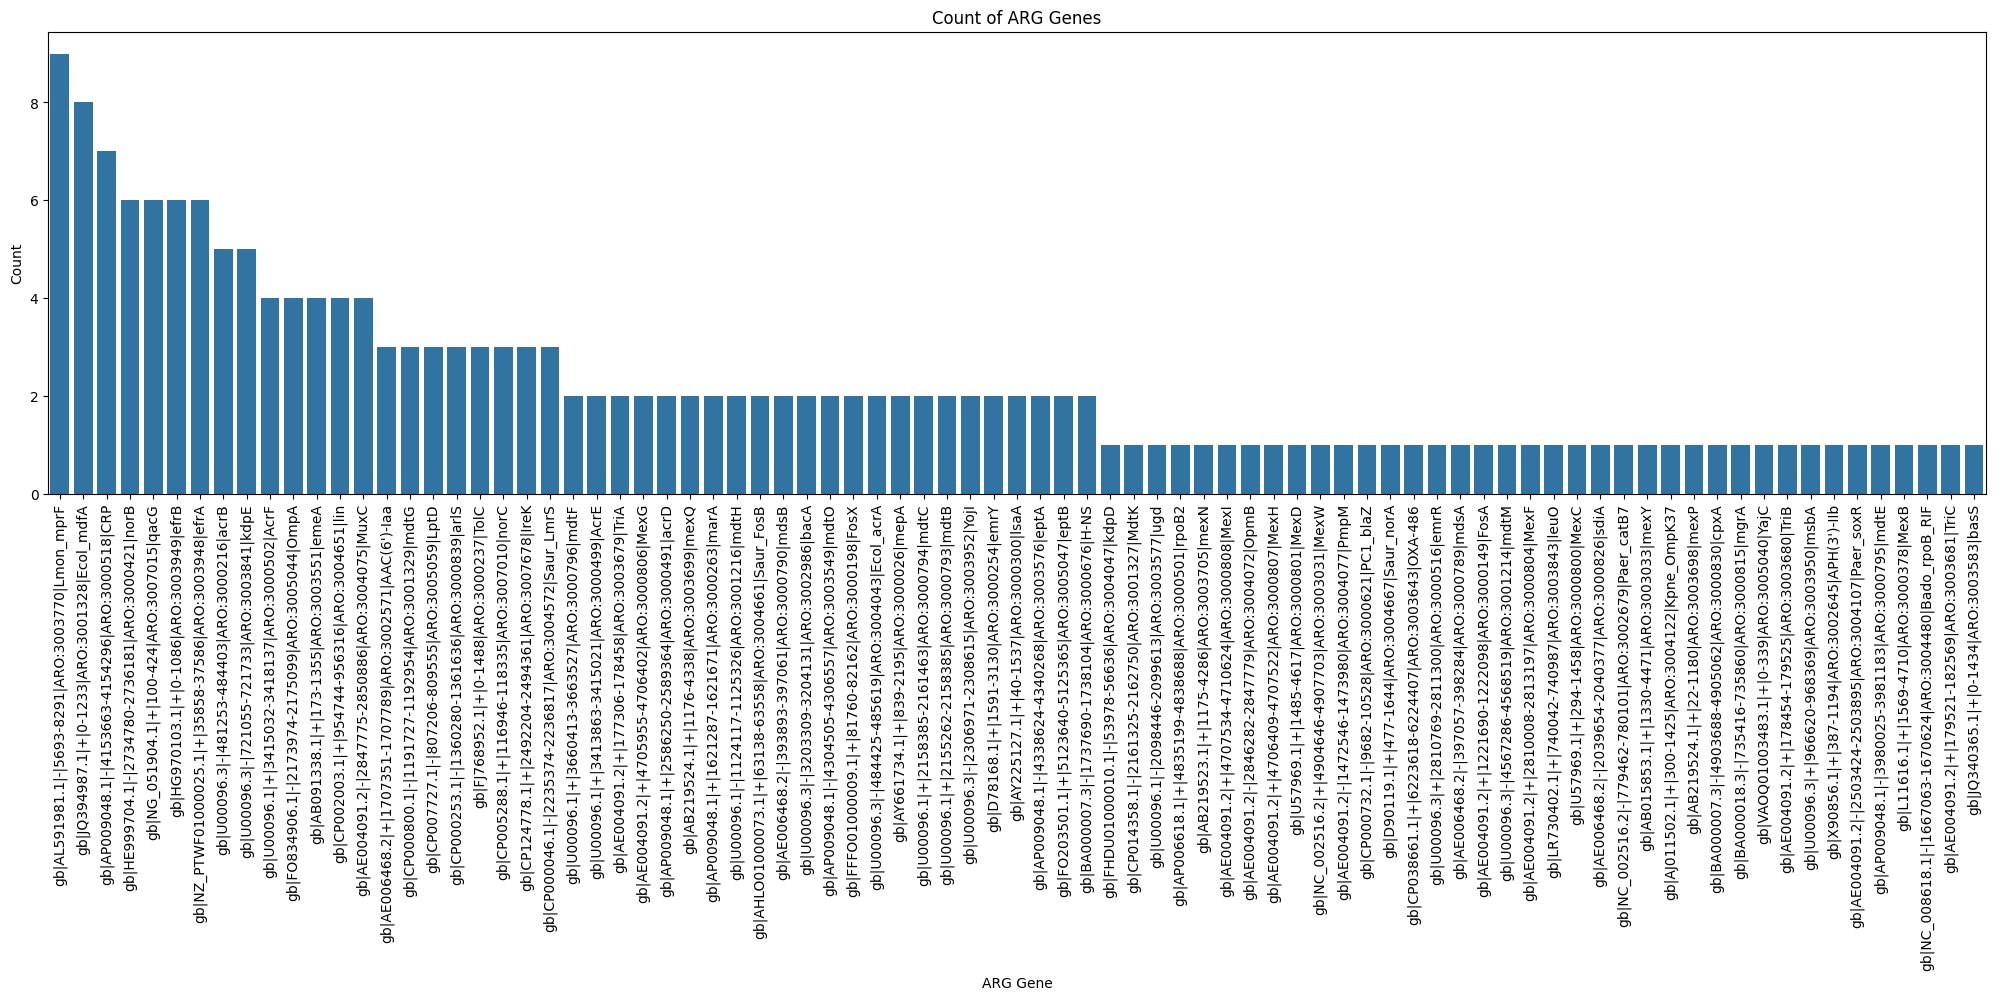

In [66]:
# Plot the count of each category in arg_gene
from matplotlib.pyplot import tight_layout

# Convert Polars DataFrame to Pandas DataFrame for plotting
df_pandas = df_predictions_arg_mge.to_pandas()

plt.figure(figsize=(25, 6))
sns.countplot(data=df_pandas, x='arg_gene', order=df_pandas['arg_gene'].value_counts().index)
plt.title('Count of ARG Genes')
plt.xlabel('ARG Gene')
plt.ylabel('Count')
plt.xticks(rotation=90)

plt.savefig(f"H6b_ARGsFound/{test_set}_ARG_abundance.png", bbox_inches='tight')
plt.show()

### Functions for calculating perofrmance (incl. precision) and plotting precision plots and confusion matrices based on y_true and y_pred

In [7]:
# Evaluate the predictions

from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

def evaluate_predictions(y_test, y_pred, json_evaluation_output):
    """Function to evaluate a classification pipelinne..
     The model will be used to make predictions on the test set.
     The predictions (y_pred) will be scored using the true labels (y_test), overall and per class.
     The scores will be saved to the file: json_evaluation_output."""

    # Per class performance
    per_class_scores = classification_report(y_test, y_pred, output_dict=True, zero_division=np.nan)
    print(f"Per class scores: \n {per_class_scores}")

    # Overall performance
    overall_scores = {
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'precision_micro': precision_score(y_test, y_pred, zero_division=np.nan, average='micro'),
        'recall_micro': recall_score(y_test, y_pred, zero_division=np.nan, average='micro'),
        'f1_micro': f1_score(y_test, y_pred, zero_division=np.nan, average='micro'),
        'precision_macro': precision_score(y_test, y_pred, zero_division=np.nan, average='macro'),
        'recall_macro': recall_score(y_test, y_pred, zero_division=np.nan, average='macro'),
        'f1_macro': f1_score(y_test, y_pred, zero_division=np.nan, average='macro'),
        'precision_weighted': precision_score(y_test, y_pred, zero_division=np.nan, average='weighted'),
        'recall_weighted': recall_score(y_test, y_pred, zero_division=np.nan, average='weighted'),
        'f1_weighted': f1_score(y_test, y_pred, zero_division=np.nan, average='weighted')
    }
    print(f"Overall scores: \n {overall_scores}")

    # Structure the data to save it to a json file
    result = {'overall_scores': overall_scores, 'per_class_scores': per_class_scores}
    # Save the results to a JSON file
    with open(json_evaluation_output, 'w') as f:
        json.dump(result, f, indent=4)

    # Format into dataframe
    per_class_scores.pop("accuracy", None)
    per_class_scores.pop("weighted avg", None)
    per_class_scores.pop('macro avg', None)
    
    # Format the per-class scores in a dataframe
    per_class_scores_flat = {'class': [], 'metric': [], 'score': []}
    for class_id, metrics in per_class_scores.items():
        for metric, score in metrics.items():
            per_class_scores_flat['class'].append(class_id)
            per_class_scores_flat['metric'].append(metric)
            per_class_scores_flat['score'].append(score)
    per_class_df = pd.DataFrame(per_class_scores_flat)

    # Format the overall scores in a dataframe
    overall_scores_flat = {'metric': [], 'score': []}
    for metric, score in overall_scores.items():
        overall_scores_flat['metric'].append(metric)
        overall_scores_flat['score'].append(score)
    overall_df = pd.DataFrame(overall_scores_flat)

    return overall_df, per_class_df

In [8]:
# Precision plot

from matplotlib.lines import Line2D

def precision_numreads_plot(precision, support, png_file, color):

    fig_width = len(precision['class'].unique())/2
    #fig_width = max(7, len(precision['class'].unique())/3)
    # Create a figure and a set of subplots
    fig, ax1 = plt.subplots(figsize=(fig_width, 3.5))

    # Plot the bar plot with hue using Seaborn
    sns.barplot(x=precision['class'], y=precision['score'], color=color, data=precision, ax=ax1)

    # #a559aa
    # #d7b5d8
    # #df65b0

    # Set the labels for the first y-axis
    ax1.set_ylabel('Precision')
    ax1.set_xlabel(f'{rank.capitalize()}')
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)

    # Create a secondary y-axis
    ax2 = ax1.twinx()

    # Plot the number of reads on the secondary y-axis
    sns.barplot(x=precision['class'], y=support["score"], color="black", data=precision, ax=ax2, width=0.3)

    # Set the labels for the secondary y-axis
    ax2.set_ylabel('Number of reads in test set')

    # Plot the legend
    precision_legend = Line2D([0], [0], color=color, lw=4, label="Precision")
    reads_legend = Line2D([0], [0], color="black", lw=4, label="Number of reads in test set")
    ax1.legend(handles=[precision_legend, reads_legend], loc='upper right')

    plt.savefig(png_file, bbox_inches='tight')

    # Show the plot
    plt.show()

In [9]:
# Confusion matrix

from matplotlib.colors import LogNorm
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, rank, scored_classes, true_classes, png_file, color):
    
    # Create a figure and a set of subplots
    figure_width = len(scored_classes)/2
    figure_height = len(true_classes)/2 * 0.8
    cm = confusion_matrix(y_true, y_pred, labels=scored_classes)
    cm = cm[~np.all(cm == 0, axis=1)]
    plt.figure(figsize=(figure_width, figure_height))
    sns.heatmap(cm, cmap="gray_r", xticklabels=scored_classes, yticklabels=true_classes, 
                annot=True, fmt='d', norm=LogNorm(), linewidths=0.5, linecolor=color, clip_on=False, square=True, 
                cbar_kws={"aspect":80}, annot_kws={"fontsize":7})
    plt.ylabel(f'True {rank}')
    plt.xlabel(f'Predicted {rank}')
    plt.savefig(png_file, bbox_inches='tight')
    #plt.show()

# Create plots for all reads with an MGE and/or ARG classification

### Assess performance

In [10]:
if test_set == "application":
    df_predictions_arg_mge = df_predictions_arg_mge.filter(pl.col("species_id").is_in(most_freq_species) & pl.col("species_id").is_not_null())

In [11]:
df_predictions_arg_mge

read_id,species_id,genus_id,family_id,sequencing_run,read_length,methylation_count,mge_score,arg_gene,AAAAANaGGT,AAAAAaGTNNNA,AAAAAaNGNNCA,AAAANGaNGCA,AAAAaNGGNANT,AAAAaTGNNCA,AAAAaTGNNCR,AAAAaTGNNYR,AAATKYcT,AAAaC,AAAaGAC,AAAaGRG,AAAaTGNDCNNT,AACCa,AACGaG,AACaCC,AACaGC,AAGAaCB,AAGAaG,AAGCGCa,AAGGaC,AAGGaG,AAGGaS,AAGRaC,AAGRaG,AAGaCC,AAGaNNNNNCTC,AAGaNTT,…,aYHYACCRT,aYNBAVYW,aYSBANYA,aYVBAVYW,cAGCCNG,cAGCGCY,cARCGCGC,cASTG,cATG,cCAGA,cCAGG,cCATGG,cCGC,cCGG,cCGGA,cCGGCNSC,cCGRG,cCNGG,cCTC,cCTCC,cCTGG,cCTTC,cCWGG,cGATCG,cGCG,cGGCCG,cGGSGCC,cTBNV,cTCGAG,cTGG,cTHH,cTNAG,cYCGRG,RF_species_pred,RF_genus_pred,SVM_species_pred,SVM_genus_pred
str,str,str,str,str,i64,i64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str
"""01e920d4-c104-…","""Salmonella ent…","""Salmonella""","""Enterobacteria…","""ZYMOMOCK_DBL""",502,13,0.945877,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.9840639,0.0,3.9840639,0.0,0.0,0.0,"""Salmonella ent…","""Salmonella""","""Salmonella ent…","""Salmonella"""
"""01f84bcc-9a71-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",749,10,0.937021,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Psychrobacter …","""Psychrobacter""","""Coprococcus sp…","""Coprococcus"""
"""033cbd30-5a0c-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",878,33,0.129703,"""gb|AP009048.1|…",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,1.1389521,1.1389521,1.1389521,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.1389521,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.1389521,0.0,0.0,0.0,"""Escherichia co…","""Escherichia""","""Escherichia co…","""Escherichia"""
"""034b279d-f2cc-…","""Pseudomonas ae…","""Pseudomonas""","""Pseudomonadace…","""ZYMOMOCK_DBL""",664,8,0.919055,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,1.5060241,1.5060241,1.5060241,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.5060241,0.0,0.0,0.0,0.0,0.0,"""Vibrio casei""","""Vibrio""","""Pseudomonas ae…","""Pseudomonas"""
"""0354e06f-ff41-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",5223,118,0.181263,"""gb|AP009048.1|…",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.191461,0.191461,0.191461,0.0,0.0,0.0,0.0,0.0,0.0,0.191461,0.0,0.0,0.0,0.0,0.0,0.0,0.191461,0.0,0.0,0.0,0.0,0.191461,0.0,0.0,0.0,0.0,1.1487651,0.0,1.1487651,0.3829217,0.0,0.0,"""Salmonella ent…","""Salmonella""","""Escherichia co…","""Escherichia"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""f7c318b7-04c1-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",570,6,0.982309,null,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,1.754386,0.0,1.754386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Vibrio casei""","""Vibrio""","""Enterococcus f…","""Enterococcus"""
"""f917d641-1a7e-…","""Enterococcus f…","""Enterococcus""","""Enterococcacea…","""ZYMOMOCK_DBL""",743,6,0.936868,null,0.0,0.0,0.0

In [12]:
output_prefix = f"{output_folder}/MGEorARG"
color = color_ARGMGE

In [13]:
# Predictions
y_pred_RF_genus = df_predictions_arg_mge.select("RF_genus_pred").to_numpy()
y_pred_RF_species = df_predictions_arg_mge.select("RF_species_pred").to_numpy()
y_pred_SVM_genus = df_predictions_arg_mge.select("SVM_genus_pred").to_numpy()
y_pred_SVM_species = df_predictions_arg_mge.select("SVM_species_pred").to_numpy()

# True labels
y_true_species = df_predictions_arg_mge.select("species_id").to_numpy()
y_true_genus = df_predictions_arg_mge.select("genus_id").to_numpy()

In [14]:
overall_scores_RF_genus, per_class_scores_RF_genus = evaluate_predictions(y_true_genus, y_pred_RF_genus, f"{output_prefix}_RF_genus.json")
overall_scores_RF_species, per_class_scores_RF_species = evaluate_predictions(y_true_species, y_pred_RF_species, f"{output_prefix}_RF_species.json")
overall_scores_SVM_genus, per_class_scores_SVM_genus = evaluate_predictions(y_true_genus, y_pred_SVM_genus, f"{output_prefix}_SVM_genus.json")
overall_scores_SVM_species, per_class_scores_SVM_species = evaluate_predictions(y_true_species, y_pred_SVM_species, f"{output_prefix}_SVM_species.json")

Per class scores: 
 {'Brevibacterium': {'precision': 0.0, 'recall': nan, 'f1-score': 0.0, 'support': 0.0}, 'Enterococcus': {'precision': 0.8947368421052632, 'recall': 0.3333333333333333, 'f1-score': 0.4857142857142857, 'support': 51.0}, 'Escherichia': {'precision': 0.8588235294117647, 'recall': 0.7087378640776699, 'f1-score': 0.776595744680851, 'support': 103.0}, 'Glutamicibacter': {'precision': 0.0, 'recall': nan, 'f1-score': 0.0, 'support': 0.0}, 'Listeria': {'precision': nan, 'recall': 0.0, 'f1-score': 0.0, 'support': 61.0}, 'Pseudomonas': {'precision': 1.0, 'recall': 0.30612244897959184, 'f1-score': 0.46875, 'support': 49.0}, 'Psychrobacter': {'precision': 0.0, 'recall': nan, 'f1-score': 0.0, 'support': 0.0}, 'Salmonella': {'precision': 0.7790697674418605, 'recall': 0.7613636363636364, 'f1-score': 0.7701149425287356, 'support': 88.0}, 'Staphylococcus': {'precision': 1.0, 'recall': 0.13043478260869565, 'f1-score': 0.23076923076923078, 'support': 46.0}, 'Vibrio': {'precision': 0.0, '

c:\Users\nicol\anaconda3\envs\methylationprofiling\lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\nicol\anaconda3\envs\methylationprofiling\lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\nicol\anaconda3\envs\methylationprofiling\lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\nicol\anaconda3\envs\methylationprofiling\lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [15]:
overall_scores_RF_genus

,metric,score
0,accuracy,0.447236
1,balanced_accuracy,0.373332
2,precision_micro,0.447236
3,recall_micro,0.447236
4,f1_micro,0.447236
5,precision_macro,0.503626
6,recall_macro,0.373332
7,f1_macro,0.273194
8,precision_weighted,0.883230
9,recall_weighted,0.447236


In [16]:
per_class_scores_RF_genus

,class,metric,score
0,Brevibacterium,precision,0.000000
1,Brevibacterium,recall,NaN
2,Brevibacterium,f1-score,0.000000
3,Brevibacterium,support,0.000000
4,Enterococcus,precision,0.894737
5,Enterococcus,recall,0.333333
6,Enterococcus,f1-score,0.485714
7,Enterococcus,support,51.000000
8,Escherichia,precision,0.858824
9,Escherichia,recall,0.708738


### Plots for RF genus and speccies

C:\Users\nicol\AppData\Local\Temp\ipykernel_8784\2530961771.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


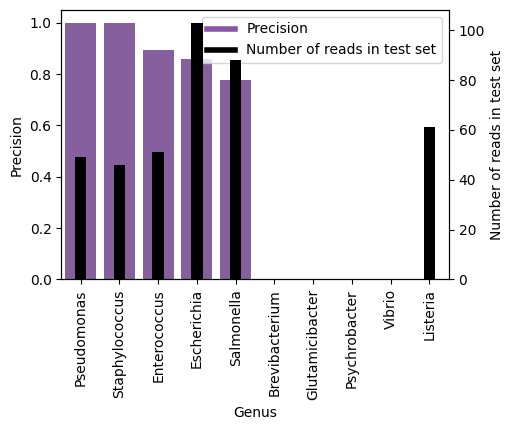

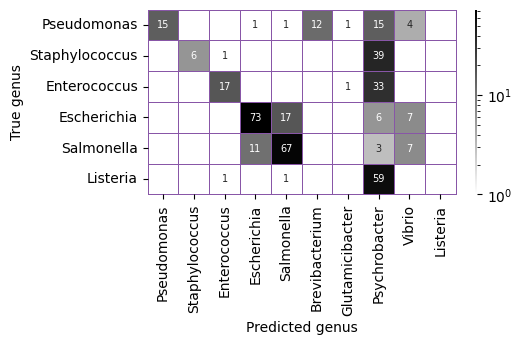

In [17]:
rank = "genus"
precision = per_class_scores_RF_genus[(per_class_scores_RF_genus["metric"]=="precision")].reset_index(drop=True).sort_values(by="score", ascending=False)
support = per_class_scores_RF_genus[(per_class_scores_RF_genus["metric"] == "support")].reset_index(drop=True)
png_file = f"{output_prefix}_precision_numreads_RF_genus.png"
precision_numreads_plot(precision, support, png_file, color)

ordered_classes = precision["class"].unique()
true_classes = [c for c in precision["class"].unique() if c in y_true_genus]
png_file = f"{output_prefix}_confusion_matrix_RF_genus.png"
plot_confusion_matrix(y_true_genus, y_pred_RF_genus, rank, ordered_classes, true_classes, png_file, color)

C:\Users\nicol\AppData\Local\Temp\ipykernel_8784\2530961771.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


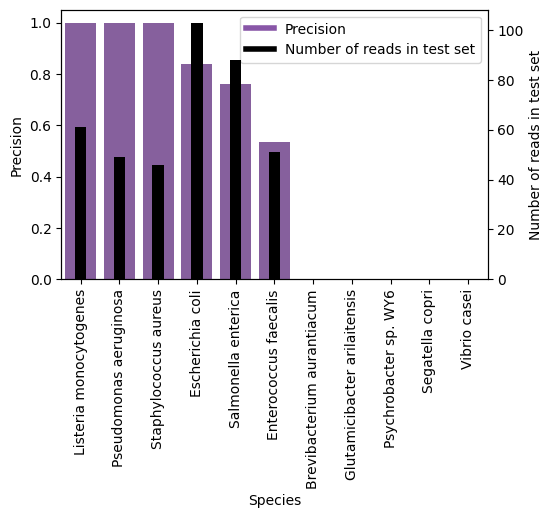

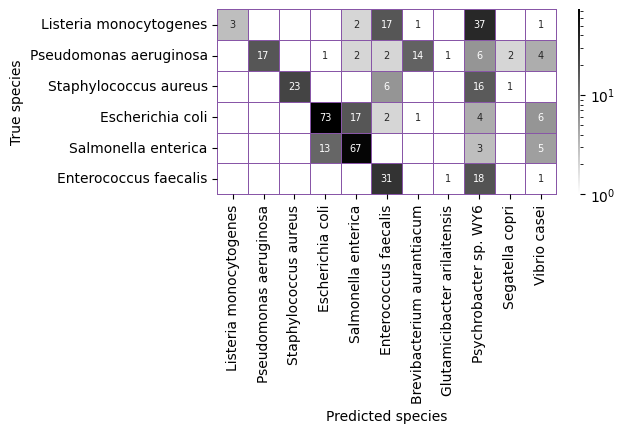

In [18]:
rank = "species"
precision = per_class_scores_RF_species[(per_class_scores_RF_species["metric"]=="precision")].reset_index(drop=True).sort_values(by="score", ascending=False)
support = per_class_scores_RF_species[(per_class_scores_RF_species["metric"] == "support")].reset_index(drop=True)
png_file = f"{output_prefix}_precision_numreads_RF_species.png"
precision_numreads_plot(precision, support, png_file, color)

ordered_classes = precision["class"].unique()
true_classes = [c for c in precision["class"].unique() if c in y_true_species]
png_file = f"{output_prefix}_confusion_matrix_RF_species.png"
plot_confusion_matrix(y_true_species, y_pred_RF_species, rank, ordered_classes, true_classes, png_file, color)

### Plots for SVM genus and species

C:\Users\nicol\AppData\Local\Temp\ipykernel_8784\2530961771.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


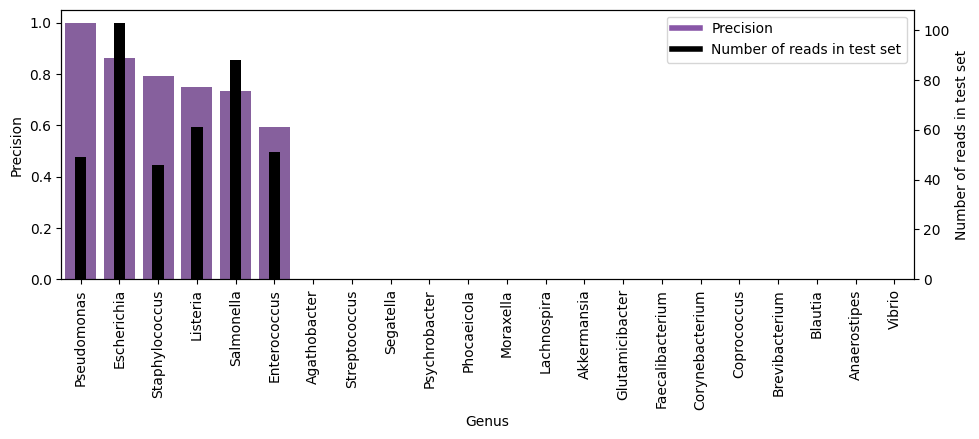

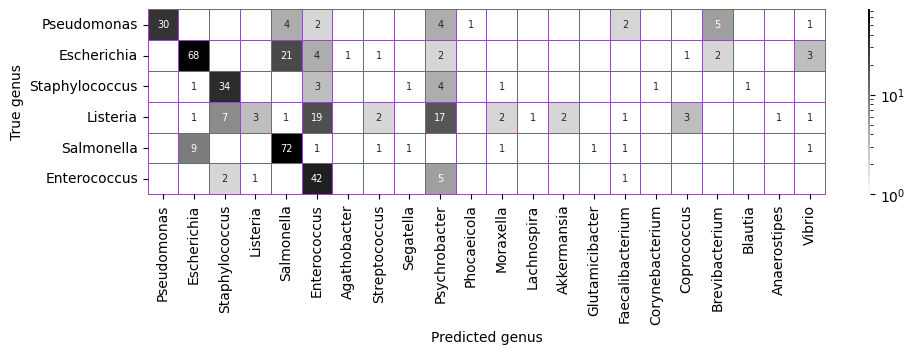

In [19]:
rank = "genus"
precision = per_class_scores_SVM_genus[(per_class_scores_SVM_genus["metric"]=="precision")].reset_index(drop=True).sort_values(by="score", ascending=False)
support = per_class_scores_SVM_genus[(per_class_scores_SVM_genus["metric"] == "support")].reset_index(drop=True)
png_file = f"{output_prefix}_precision_numreads_SVM_genus.png"
precision_numreads_plot(precision, support, png_file, color)

ordered_classes = precision["class"].unique()
true_classes = [c for c in precision["class"].unique() if c in y_true_genus]
png_file = f"{output_prefix}_confusion_matrix_SVM_genus.png"
plot_confusion_matrix(y_true_genus, y_pred_SVM_genus, rank, ordered_classes, true_classes, png_file, color)

C:\Users\nicol\AppData\Local\Temp\ipykernel_8784\2530961771.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


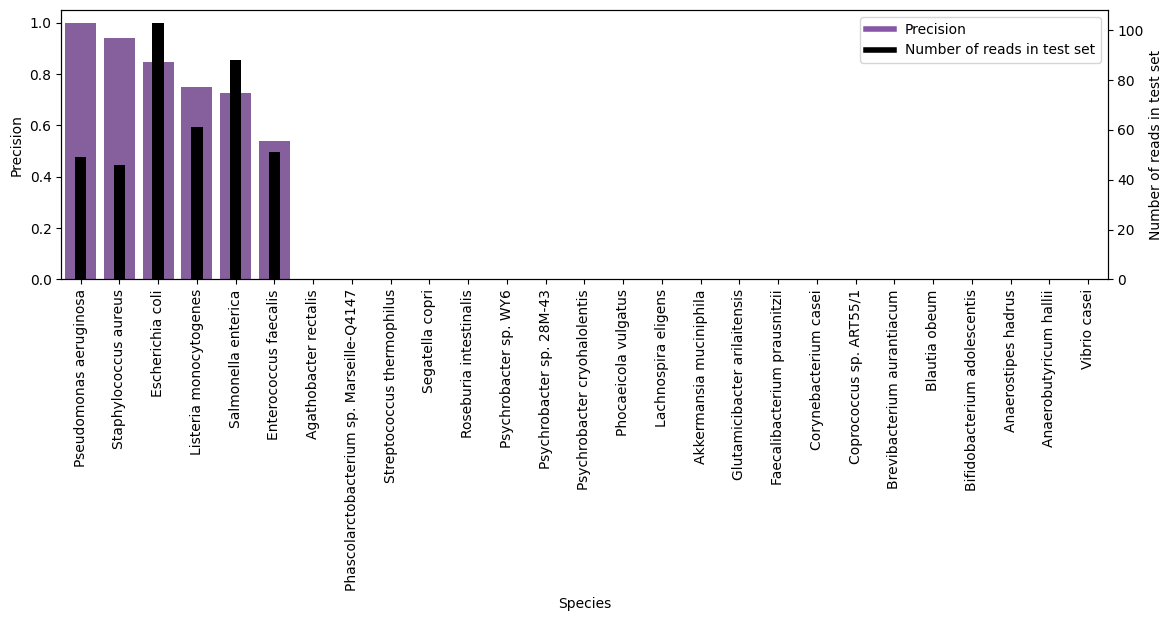

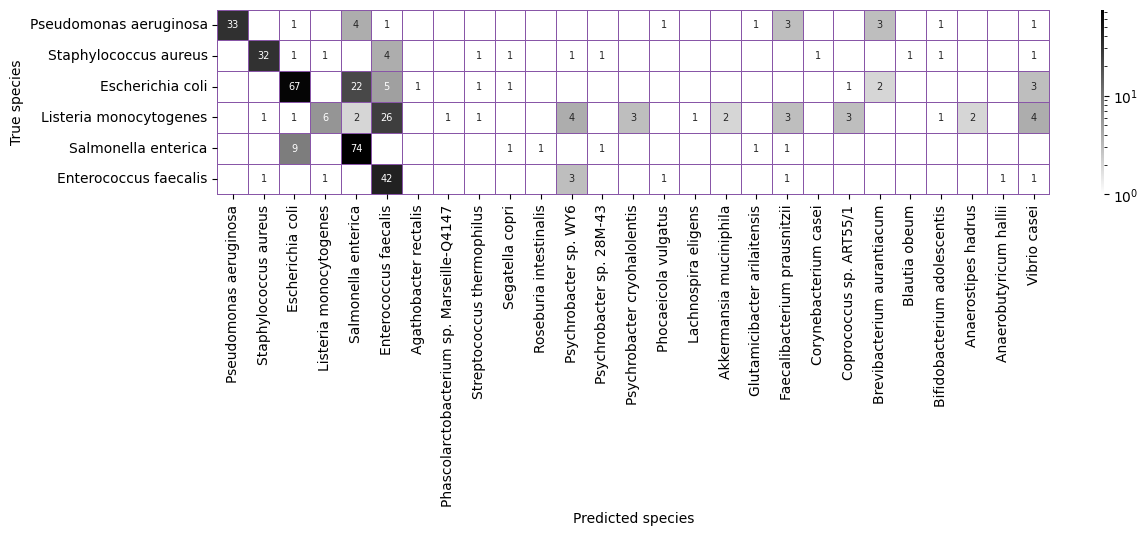

In [20]:
rank = "species"
precision = per_class_scores_SVM_species[(per_class_scores_SVM_species["metric"]=="precision")].reset_index(drop=True).sort_values(by="score", ascending=False)
support = per_class_scores_SVM_species[(per_class_scores_SVM_species["metric"] == "support")].reset_index(drop=True)
png_file = f"{output_prefix}_precision_numreads_SVM_species.png"
precision_numreads_plot(precision, support, png_file, color)

ordered_classes = precision["class"].unique()
true_classes = [c for c in precision["class"].unique() if c in y_true_species]
png_file = f"{output_prefix}_confusion_matrix_SVM_species.png"
plot_confusion_matrix(y_true_species, y_pred_SVM_species, rank, ordered_classes, true_classes, png_file, color)

# Create plots for all reads with an MGE classification

### Assess performance

In [21]:
#df_predictions_arg_mge = df_predictions_arg_mge.filter(pl.col("species_id").is_not_null())

In [22]:
# Reads which are classified as plasmid
df_plasmids = df_predictions_arg_mge.filter((pl.col("mge_score") > 0.9))

In [23]:
print("Nr of reads that are a plasmid: ")
print(df_plasmids.shape)

Nr of reads that are a plasmid: 
(214, 4193)


In [24]:
output_prefix = f"{output_folder}_MGE"
color = color_MGE

In [25]:
# Predictions
y_pred_RF_genus = df_plasmids.select("RF_genus_pred").to_numpy()
y_pred_RF_species = df_plasmids.select("RF_species_pred").to_numpy()
y_pred_SVM_genus = df_plasmids.select("SVM_genus_pred").to_numpy()
y_pred_SVM_species = df_plasmids.select("SVM_species_pred").to_numpy()

# True labels
y_true_species = df_plasmids.select("species_id").to_numpy()
y_true_genus = df_plasmids.select("genus_id").to_numpy()

In [26]:
overall_scores_RF_genus, per_class_scores_RF_genus = evaluate_predictions(y_true_genus, y_pred_RF_genus, f"{output_prefix}_RF_genus.json")
overall_scores_RF_species, per_class_scores_RF_species = evaluate_predictions(y_true_species, y_pred_RF_species, f"{output_prefix}_RF_species.json")
overall_scores_SVM_genus, per_class_scores_SVM_genus = evaluate_predictions(y_true_genus, y_pred_SVM_genus, f"{output_prefix}_SVM_genus.json")
overall_scores_SVM_species, per_class_scores_SVM_species = evaluate_predictions(y_true_species, y_pred_SVM_species, f"{output_prefix}_SVM_species.json")

Per class scores: 
 {'Brevibacterium': {'precision': 0.0, 'recall': nan, 'f1-score': 0.0, 'support': 0.0}, 'Enterococcus': {'precision': 1.0, 'recall': 0.26666666666666666, 'f1-score': 0.42105263157894735, 'support': 30.0}, 'Escherichia': {'precision': 0.8, 'recall': 0.64, 'f1-score': 0.7111111111111111, 'support': 50.0}, 'Listeria': {'precision': nan, 'recall': 0.0, 'f1-score': 0.0, 'support': 40.0}, 'Pseudomonas': {'precision': 1.0, 'recall': 0.11764705882352941, 'f1-score': 0.21052631578947367, 'support': 17.0}, 'Psychrobacter': {'precision': 0.0, 'recall': nan, 'f1-score': 0.0, 'support': 0.0}, 'Salmonella': {'precision': 0.8085106382978723, 'recall': 0.7037037037037037, 'f1-score': 0.7524752475247525, 'support': 54.0}, 'Staphylococcus': {'precision': 1.0, 'recall': 0.043478260869565216, 'f1-score': 0.08333333333333333, 'support': 23.0}, 'Vibrio': {'precision': 0.0, 'recall': nan, 'f1-score': 0.0, 'support': 0.0}, 'accuracy': 0.37850467289719625, 'macro avg': {'precision': 0.576063

c:\Users\nicol\anaconda3\envs\methylationprofiling\lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\nicol\anaconda3\envs\methylationprofiling\lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\nicol\anaconda3\envs\methylationprofiling\lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\nicol\anaconda3\envs\methylationprofiling\lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [27]:
overall_scores_RF_genus

,metric,score
0,accuracy,0.378505
1,balanced_accuracy,0.295249
2,precision_micro,0.378505
3,recall_micro,0.378505
4,f1_micro,0.378505
5,precision_macro,0.576064
6,recall_macro,0.295249
7,f1_macro,0.242055
8,precision_weighted,0.883101
9,recall_weighted,0.378505


In [28]:
per_class_scores_RF_genus

,class,metric,score
0,Brevibacterium,precision,0.000000
1,Brevibacterium,recall,NaN
2,Brevibacterium,f1-score,0.000000
3,Brevibacterium,support,0.000000
4,Enterococcus,precision,1.000000
5,Enterococcus,recall,0.266667
6,Enterococcus,f1-score,0.421053
7,Enterococcus,support,30.000000
8,Escherichia,precision,0.800000
9,Escherichia,recall,0.640000


### Plots for RF genus and speccies

C:\Users\nicol\AppData\Local\Temp\ipykernel_8784\2530961771.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


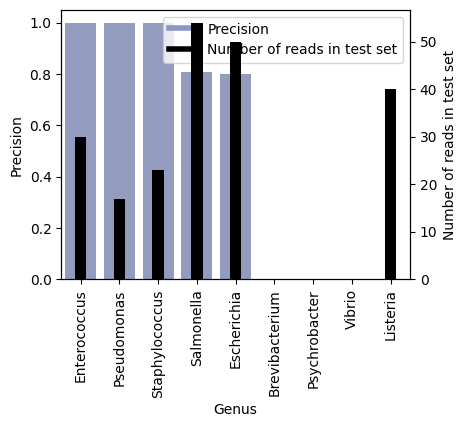

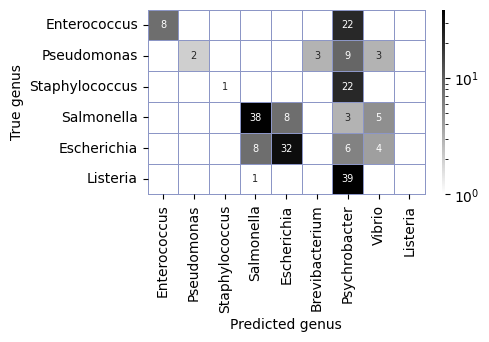

In [29]:
rank = "genus"
precision = per_class_scores_RF_genus[(per_class_scores_RF_genus["metric"]=="precision")].reset_index(drop=True).sort_values(by="score", ascending=False)
support = per_class_scores_RF_genus[(per_class_scores_RF_genus["metric"] == "support")].reset_index(drop=True)
png_file = f"{output_prefix}_precision_numreads_RF_genus.png"
precision_numreads_plot(precision, support, png_file, color)

ordered_classes = precision["class"].unique()
true_classes = [c for c in precision["class"].unique() if c in y_true_genus]
png_file = f"{output_prefix}_confusion_matrix_RF_genus.png"
plot_confusion_matrix(y_true_genus, y_pred_RF_genus, rank, ordered_classes, true_classes, png_file, color)

C:\Users\nicol\AppData\Local\Temp\ipykernel_8784\2530961771.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


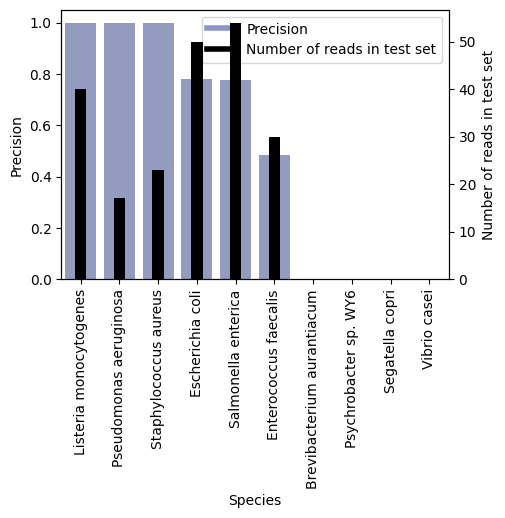

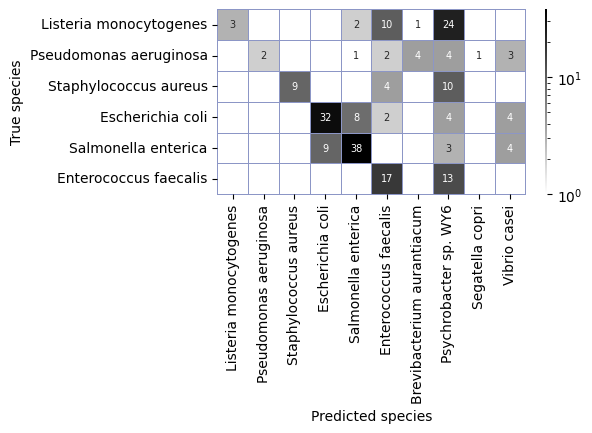

In [30]:
rank = "species"
precision = per_class_scores_RF_species[(per_class_scores_RF_species["metric"]=="precision")].reset_index(drop=True).sort_values(by="score", ascending=False)
support = per_class_scores_RF_species[(per_class_scores_RF_species["metric"] == "support")].reset_index(drop=True)
png_file = f"{output_prefix}_precision_numreads_RF_species.png"
precision_numreads_plot(precision, support, png_file, color)

ordered_classes = precision["class"].unique()
true_classes = [c for c in precision["class"].unique() if c in y_true_species]
png_file = f"{output_prefix}_confusion_matrix_RF_species.png"
plot_confusion_matrix(y_true_species, y_pred_RF_species, rank, ordered_classes, true_classes, png_file, color)

### Plots for SVM genus and species

C:\Users\nicol\AppData\Local\Temp\ipykernel_8784\2530961771.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


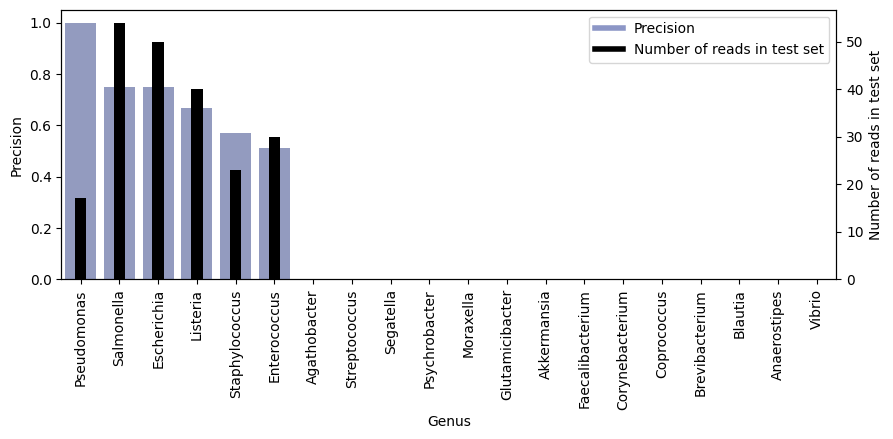

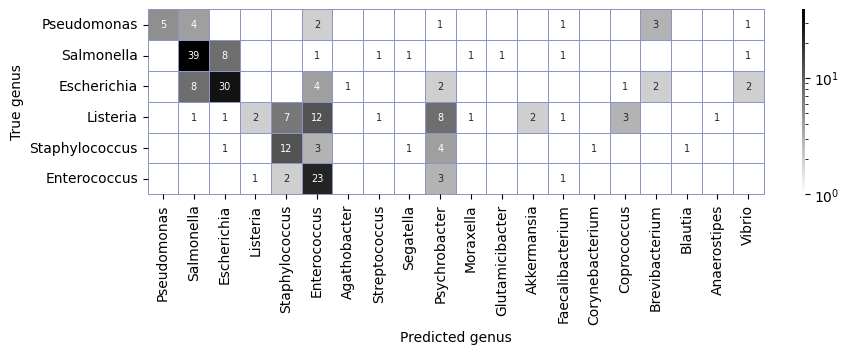

In [31]:
rank = "genus"
precision = per_class_scores_SVM_genus[(per_class_scores_SVM_genus["metric"]=="precision")].reset_index(drop=True).sort_values(by="score", ascending=False)
support = per_class_scores_SVM_genus[(per_class_scores_SVM_genus["metric"] == "support")].reset_index(drop=True)
png_file = f"{output_prefix}_precision_numreads_SVM_genus.png"
precision_numreads_plot(precision, support, png_file, color)

ordered_classes = precision["class"].unique()
true_classes = [c for c in precision["class"].unique() if c in y_true_genus]
png_file = f"{output_prefix}_confusion_matrix_SVM_genus.png"
plot_confusion_matrix(y_true_genus, y_pred_SVM_genus, rank, ordered_classes, true_classes, png_file, color)

C:\Users\nicol\AppData\Local\Temp\ipykernel_8784\2530961771.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


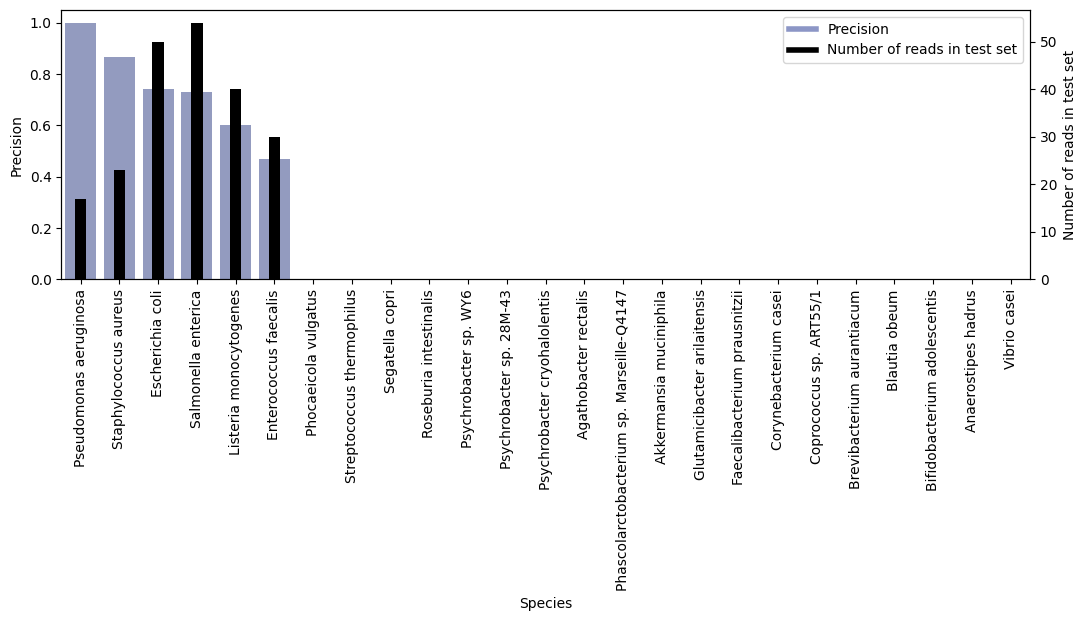

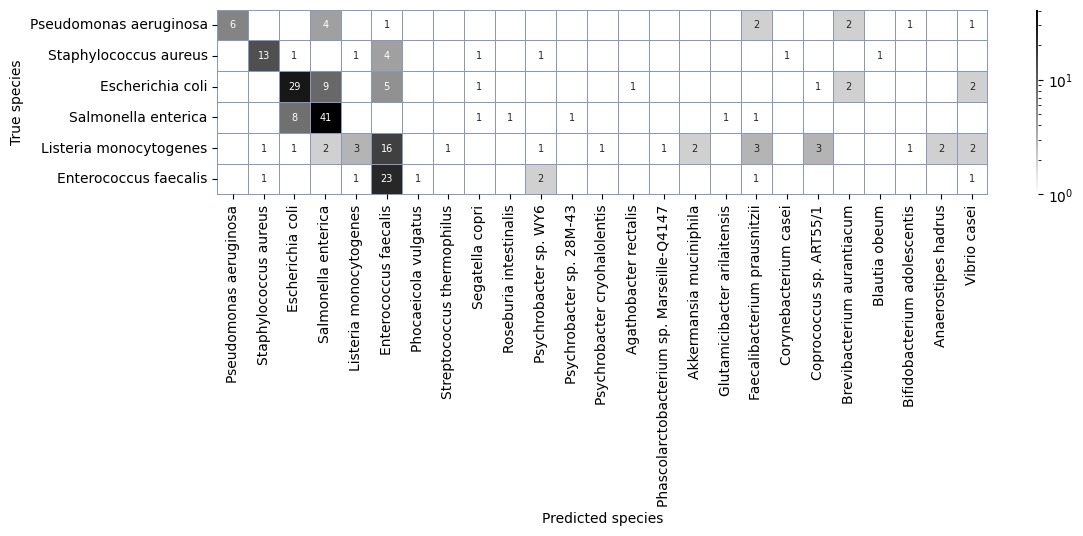

In [32]:
rank = "species"
precision = per_class_scores_SVM_species[(per_class_scores_SVM_species["metric"]=="precision")].reset_index(drop=True).sort_values(by="score", ascending=False)
support = per_class_scores_SVM_species[(per_class_scores_SVM_species["metric"] == "support")].reset_index(drop=True)
png_file = f"{output_prefix}_precision_numreads_SVM_species.png"
precision_numreads_plot(precision, support, png_file, color)

ordered_classes = precision["class"].unique()
true_classes = [c for c in precision["class"].unique() if c in y_true_species]
png_file = f"{output_prefix}_confusion_matrix_SVM_species.png"
plot_confusion_matrix(y_true_species, y_pred_SVM_species, rank, ordered_classes, true_classes, png_file, color)

# Create plots for all reads with an ARG classification

### Assess performance

In [33]:
#df_predictions_arg_mge = df_predictions_arg_mge.filter(pl.col("species_id").is_not_null())

In [34]:
# Reads which are classified as plasmid
df_args = df_predictions_arg_mge.filter(pl.col("arg_gene").is_not_null())

In [35]:
df_args.shape

(186, 4193)

In [36]:
output_prefix = f"{output_folder}_ARG"
color = color_ARG

In [37]:
# Predictions
y_pred_RF_genus = df_args.select("RF_genus_pred").to_numpy()
y_pred_RF_species = df_args.select("RF_species_pred").to_numpy()
y_pred_SVM_genus = df_args.select("SVM_genus_pred").to_numpy()
y_pred_SVM_species = df_args.select("SVM_species_pred").to_numpy()

# True labels
y_true_species = df_args.select("species_id").to_numpy()
y_true_genus = df_args.select("genus_id").to_numpy()

In [38]:
overall_scores_RF_genus, per_class_scores_RF_genus = evaluate_predictions(y_true_genus, y_pred_RF_genus, f"{output_prefix}_RF_genus.json")
overall_scores_RF_species, per_class_scores_RF_species = evaluate_predictions(y_true_species, y_pred_RF_species, f"{output_prefix}_RF_species.json")
overall_scores_SVM_genus, per_class_scores_SVM_genus = evaluate_predictions(y_true_genus, y_pred_SVM_genus, f"{output_prefix}_SVM_genus.json")
overall_scores_SVM_species, per_class_scores_SVM_species = evaluate_predictions(y_true_species, y_pred_SVM_species, f"{output_prefix}_SVM_species.json")

Per class scores: 
 {'Brevibacterium': {'precision': 0.0, 'recall': nan, 'f1-score': 0.0, 'support': 0.0}, 'Enterococcus': {'precision': 0.8181818181818182, 'recall': 0.42857142857142855, 'f1-score': 0.5625, 'support': 21.0}, 'Escherichia': {'precision': 0.9130434782608695, 'recall': 0.7777777777777778, 'f1-score': 0.84, 'support': 54.0}, 'Glutamicibacter': {'precision': 0.0, 'recall': nan, 'f1-score': 0.0, 'support': 0.0}, 'Listeria': {'precision': nan, 'recall': 0.0, 'f1-score': 0.0, 'support': 21.0}, 'Pseudomonas': {'precision': 1.0, 'recall': 0.3939393939393939, 'f1-score': 0.5652173913043478, 'support': 33.0}, 'Psychrobacter': {'precision': 0.0, 'recall': nan, 'f1-score': 0.0, 'support': 0.0}, 'Salmonella': {'precision': 0.7435897435897436, 'recall': 0.8529411764705882, 'f1-score': 0.7945205479452054, 'support': 34.0}, 'Staphylococcus': {'precision': 1.0, 'recall': 0.21739130434782608, 'f1-score': 0.35714285714285715, 'support': 23.0}, 'Vibrio': {'precision': 0.0, 'recall': nan, '

c:\Users\nicol\anaconda3\envs\methylationprofiling\lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\nicol\anaconda3\envs\methylationprofiling\lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\nicol\anaconda3\envs\methylationprofiling\lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\nicol\anaconda3\envs\methylationprofiling\lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [39]:
overall_scores_RF_genus

,metric,score
0,accuracy,0.526882
1,balanced_accuracy,0.445104
2,precision_micro,0.526882
3,recall_micro,0.526882
4,f1_micro,0.526882
5,precision_macro,0.497202
6,recall_macro,0.445104
7,f1_macro,0.311938
8,precision_weighted,0.895565
9,recall_weighted,0.526882


In [40]:
per_class_scores_RF_genus

,class,metric,score
0,Brevibacterium,precision,0.000000
1,Brevibacterium,recall,NaN
2,Brevibacterium,f1-score,0.000000
3,Brevibacterium,support,0.000000
4,Enterococcus,precision,0.818182
5,Enterococcus,recall,0.428571
6,Enterococcus,f1-score,0.562500
7,Enterococcus,support,21.000000
8,Escherichia,precision,0.913043
9,Escherichia,recall,0.777778


### Plots for RF genus and speccies

C:\Users\nicol\AppData\Local\Temp\ipykernel_8784\2530961771.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


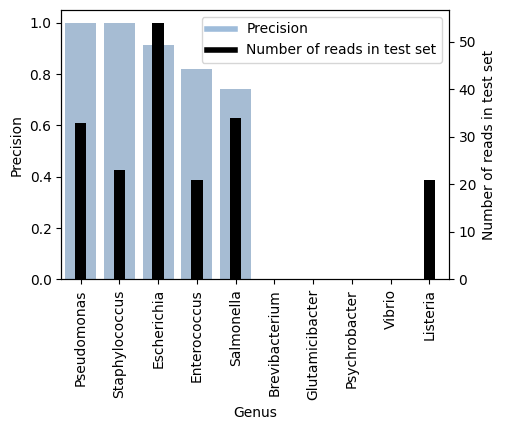

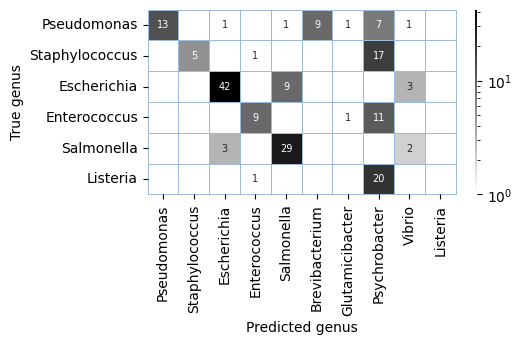

In [41]:
rank = "genus"
precision = per_class_scores_RF_genus[(per_class_scores_RF_genus["metric"]=="precision")].reset_index(drop=True).sort_values(by="score", ascending=False)
support = per_class_scores_RF_genus[(per_class_scores_RF_genus["metric"] == "support")].reset_index(drop=True)
png_file = f"{output_prefix}_precision_numreads_RF_genus.png"
precision_numreads_plot(precision, support, png_file, color)

ordered_classes = precision["class"].unique()
true_classes = [c for c in precision["class"].unique() if c in y_true_genus]
png_file = f"{output_prefix}_confusion_matrix_RF_genus.png"
plot_confusion_matrix(y_true_genus, y_pred_RF_genus, rank, ordered_classes, true_classes, png_file, color)

C:\Users\nicol\AppData\Local\Temp\ipykernel_8784\2530961771.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


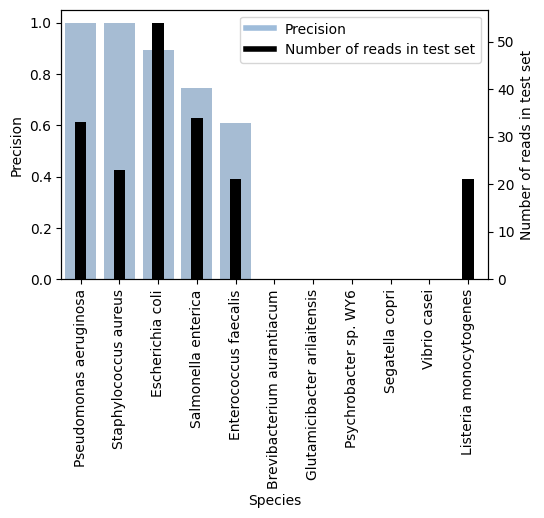

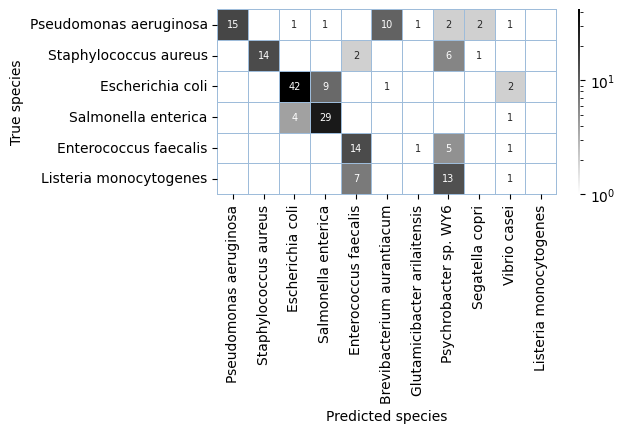

In [42]:
rank = "species"
precision = per_class_scores_RF_species[(per_class_scores_RF_species["metric"]=="precision")].reset_index(drop=True).sort_values(by="score", ascending=False)
support = per_class_scores_RF_species[(per_class_scores_RF_species["metric"] == "support")].reset_index(drop=True)
png_file = f"{output_prefix}_precision_numreads_RF_species.png"
precision_numreads_plot(precision, support, png_file, color)

ordered_classes = precision["class"].unique()
true_classes = [c for c in precision["class"].unique() if c in y_true_species]
png_file = f"{output_prefix}_confusion_matrix_RF_species.png"
plot_confusion_matrix(y_true_species, y_pred_RF_species, rank, ordered_classes, true_classes, png_file, color)

### Plots for SVM genus and species

C:\Users\nicol\AppData\Local\Temp\ipykernel_8784\2530961771.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


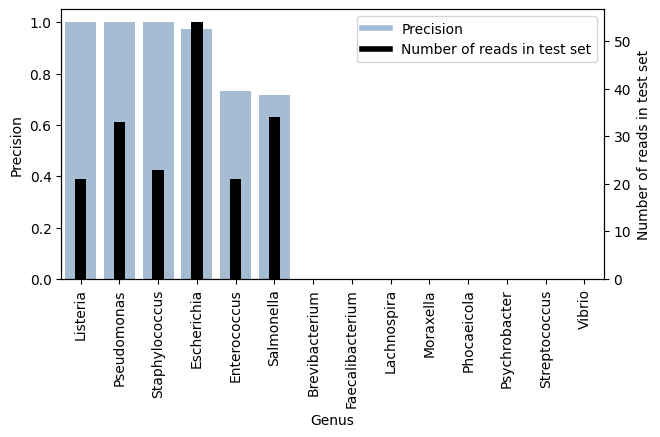

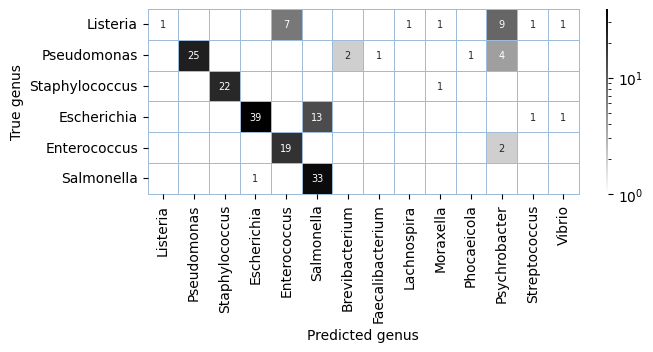

In [43]:
rank = "genus"
precision = per_class_scores_SVM_genus[(per_class_scores_SVM_genus["metric"]=="precision")].reset_index(drop=True).sort_values(by="score", ascending=False)
support = per_class_scores_SVM_genus[(per_class_scores_SVM_genus["metric"] == "support")].reset_index(drop=True)
png_file = f"{output_prefix}_precision_numreads_SVM_genus.png"
precision_numreads_plot(precision, support, png_file, color)

ordered_classes = precision["class"].unique()
true_classes = [c for c in precision["class"].unique() if c in y_true_genus]
png_file = f"{output_prefix}_confusion_matrix_SVM_genus.png"
plot_confusion_matrix(y_true_genus, y_pred_SVM_genus, rank, ordered_classes, true_classes, png_file, color)

C:\Users\nicol\AppData\Local\Temp\ipykernel_8784\2530961771.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


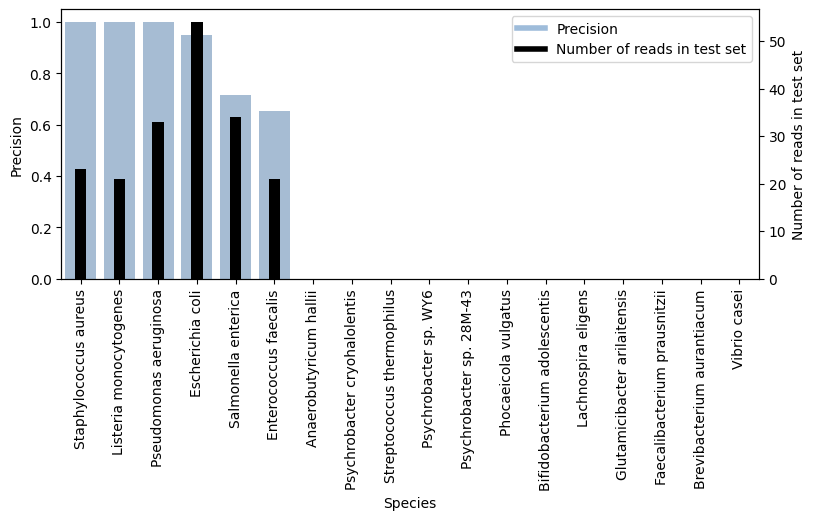

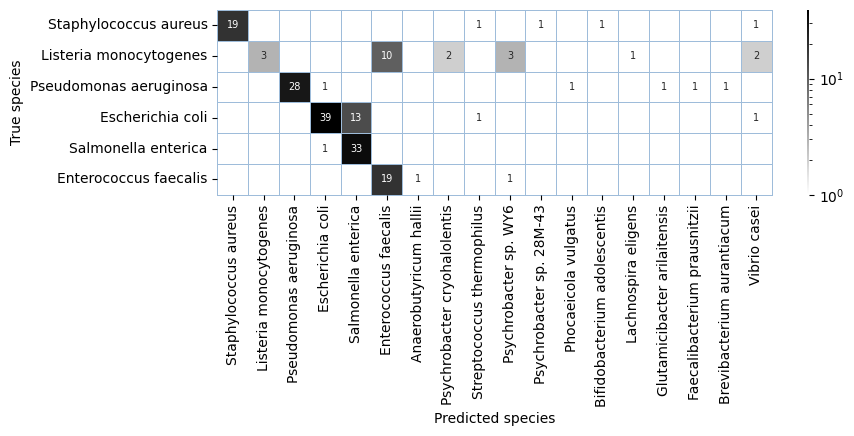

In [44]:
rank = "species"
precision = per_class_scores_SVM_species[(per_class_scores_SVM_species["metric"]=="precision")].reset_index(drop=True).sort_values(by="score", ascending=False)
support = per_class_scores_SVM_species[(per_class_scores_SVM_species["metric"] == "support")].reset_index(drop=True)
png_file = f"{output_prefix}_precision_numreads_SVM_species.png"
precision_numreads_plot(precision, support, png_file, color)

ordered_classes = precision["class"].unique()
true_classes = [c for c in precision["class"].unique() if c in y_true_species]
png_file = f"{output_prefix}_confusion_matrix_SVM_species.png"
plot_confusion_matrix(y_true_species, y_pred_SVM_species, rank, ordered_classes, true_classes, png_file, color)

# Compare ARG results with CARD taxonomic annotations

In [45]:
# For the application data: load all reads (also not annotated with top50 species)
if test_set == "application":
    df_predictions_arg_mge = pl.read_csv(tsv_predictions_arg_mge, separator='\t', has_header=True)
    df_predictions_arg_mge

df_args = df_predictions_arg_mge.filter(pl.col("arg_gene").is_not_null())

In [46]:
df_args

read_id,species_id,genus_id,family_id,sequencing_run,read_length,methylation_count,mge_score,arg_gene,AAAAANaGGT,AAAAAaGTNNNA,AAAAAaNGNNCA,AAAANGaNGCA,AAAAaNGGNANT,AAAAaTGNNCA,AAAAaTGNNCR,AAAAaTGNNYR,AAATKYcT,AAAaC,AAAaGAC,AAAaGRG,AAAaTGNDCNNT,AACCa,AACGaG,AACaCC,AACaGC,AAGAaCB,AAGAaG,AAGCGCa,AAGGaC,AAGGaG,AAGGaS,AAGRaC,AAGRaG,AAGaCC,AAGaNNNNNCTC,AAGaNTT,…,aYHYACCRT,aYNBAVYW,aYSBANYA,aYVBAVYW,cAGCCNG,cAGCGCY,cARCGCGC,cASTG,cATG,cCAGA,cCAGG,cCATGG,cCGC,cCGG,cCGGA,cCGGCNSC,cCGRG,cCNGG,cCTC,cCTCC,cCTGG,cCTTC,cCWGG,cGATCG,cGCG,cGGCCG,cGGSGCC,cTBNV,cTCGAG,cTGG,cTHH,cTNAG,cYCGRG,RF_species_pred,RF_genus_pred,SVM_species_pred,SVM_genus_pred
str,str,str,str,str,i64,i64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str
"""033cbd30-5a0c-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",878,33,0.129703,"""gb|AP009048.1|…",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,1.1389521,1.1389521,1.1389521,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.1389521,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.1389521,0.0,0.0,0.0,"""Escherichia co…","""Escherichia""","""Escherichia co…","""Escherichia"""
"""0354e06f-ff41-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",5223,118,0.181263,"""gb|AP009048.1|…",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.191461,0.191461,0.191461,0.0,0.0,0.0,0.0,0.0,0.0,0.191461,0.0,0.0,0.0,0.0,0.0,0.0,0.191461,0.0,0.0,0.0,0.0,0.191461,0.0,0.0,0.0,0.0,1.1487651,0.0,1.1487651,0.3829217,0.0,0.0,"""Salmonella ent…","""Salmonella""","""Escherichia co…","""Escherichia"""
"""04dea58d-1fe5-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",1344,15,0.825665,"""gb|JQ394987.1|…",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.4880953,0.0,1.4880953,0.0,0.0,0.0,"""Escherichia co…","""Escherichia""","""Escherichia co…","""Escherichia"""
"""0533017e-7cd2-…","""Pseudomonas ae…","""Pseudomonas""","""Pseudomonadace…","""ZYMOMOCK_DBL""",1016,17,0.004655,"""gb|AE004091.2|…",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.984252,0.0,0.0,0.984252,0.0,0.0,"""Brevibacterium…","""Brevibacterium…","""Pseudomonas ae…","""Brevibacterium…"
"""05723645-8e7e-…","""Salmonella ent…","""Salmonella""","""Enterobacteria…","""ZYMOMOCK_DBL""",4983,117,0.109716,"""gb|AP009048.1|…",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.200682,0.0,0.0,…,0.0,0.602047,0.401365,0.401365,0.0,0.0,0.0,0.0,0.0,0.0,0.401365,0.0,0.0,0.0,0.0,0.0,0.0,0.401365,0.0,0.0,0.0,0.0,0.401365,0.0,0.0,0.0,0.0,1.6054586,0.0,1.8061409,0.602047,0.0,0.0,"""Salmonella ent…","""Salmonella""","""Salmonella ent…","""Salmonella"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""88b0cffc-3571-…","""Listeria monoc…","""Listeria""","""Listeriaceae""","""ZYMOMOCK_DBL""",1383,4,0.437081,"""gb|CP002003.1|…",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Psychrobacter …","""Psychrobacter""","""Listeria monoc…","""Listeria"""
"""8b6b13f0-0c48-…","""Ente

In [47]:
# Load CARD prevalance database
card_prevalence = pl.read_csv(card_prevalence_data, separator='\t', has_header=True)
card_prevalence

ARO Accession,Name,Model ID,Model Type,Pathogen,NCBI Plasmid,NCBI WGS,NCBI Chromosome,NCBI Genomic Island,Criteria,ARO Categories
str,str,i64,str,str,f64,f64,f64,f64,str,str
"""ARO:3002999""","""CblA-1""",2,"""protein homolo…","""Phocaeicola do…",0.0,1.04,0.0,0.0,"""perfect""","""antibiotic ina…"
"""ARO:3002999""","""CblA-1""",2,"""protein homolo…","""Phocaeicola do…",0.0,1.04,0.0,0.0,"""perfect_strict…","""antibiotic ina…"
"""ARO:3003390""","""Escherichia co…",3,"""protein varian…","""Escherichia co…",0.0,0.01,0.0,0.0,"""perfect_strict…","""carbapenem; ce…"
"""ARO:3001109""","""SHV-52""",4,"""protein homolo…","""Klebsiella pne…",0.0,0.09,0.0,0.0,"""perfect""","""antibiotic ina…"
"""ARO:3001109""","""SHV-52""",4,"""protein homolo…","""Klebsiella pne…",0.0,0.09,0.0,0.0,"""perfect_strict…","""antibiotic ina…"
…,…,…,…,…,…,…,…,…,…,…
"""ARO:3007473""","""Mycobacterium …",5956,"""protein varian…","""Corynebacteriu…",0.0,0.63,0.0,0.0,"""perfect_strict…","""antibiotic tar…"
"""ARO:3007473""","""Mycobacterium …",5956,"""protein varian…","""Corynebacteriu…",0.0,60.0,0.0,0.0,"""perfect_strict…","""antibiotic tar…"
"""ARO:3007473""","""Mycobacterium …",5956,"""protein varian…","""Corynebacteriu…",0.0,4.55,0.0,0.0,"""perfect_strict…","""antibiotic tar…"


In [48]:
# Number of reads from ouor data with an ARG
print(f"Nr of reads with an ARG in our data: {df_args.shape[0]}")
df_args.head()

# independent test: Nr of reads with an ARG in our data: 186

Nr of reads with an ARG in our data: 186


read_id,species_id,genus_id,family_id,sequencing_run,read_length,methylation_count,mge_score,arg_gene,AAAAANaGGT,AAAAAaGTNNNA,AAAAAaNGNNCA,AAAANGaNGCA,AAAAaNGGNANT,AAAAaTGNNCA,AAAAaTGNNCR,AAAAaTGNNYR,AAATKYcT,AAAaC,AAAaGAC,AAAaGRG,AAAaTGNDCNNT,AACCa,AACGaG,AACaCC,AACaGC,AAGAaCB,AAGAaG,AAGCGCa,AAGGaC,AAGGaG,AAGGaS,AAGRaC,AAGRaG,AAGaCC,AAGaNNNNNCTC,AAGaNTT,…,aYHYACCRT,aYNBAVYW,aYSBANYA,aYVBAVYW,cAGCCNG,cAGCGCY,cARCGCGC,cASTG,cATG,cCAGA,cCAGG,cCATGG,cCGC,cCGG,cCGGA,cCGGCNSC,cCGRG,cCNGG,cCTC,cCTCC,cCTGG,cCTTC,cCWGG,cGATCG,cGCG,cGGCCG,cGGSGCC,cTBNV,cTCGAG,cTGG,cTHH,cTNAG,cYCGRG,RF_species_pred,RF_genus_pred,SVM_species_pred,SVM_genus_pred
str,str,str,str,str,i64,i64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str
"""033cbd30-5a0c-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",878,33,0.129703,"""gb|AP009048.1|…",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,1.1389521,1.1389521,1.1389521,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.1389521,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.1389521,0.0,0.0,0.0,"""Escherichia co…","""Escherichia""","""Escherichia co…","""Escherichia"""
"""0354e06f-ff41-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",5223,118,0.181263,"""gb|AP009048.1|…",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.191461,0.191461,0.191461,0.0,0.0,0.0,0.0,0.0,0.0,0.191461,0.0,0.0,0.0,0.0,0.0,0.0,0.191461,0.0,0.0,0.0,0.0,0.191461,0.0,0.0,0.0,0.0,1.1487651,0.0,1.1487651,0.3829217,0.0,0.0,"""Salmonella ent…","""Salmonella""","""Escherichia co…","""Escherichia"""
"""04dea58d-1fe5-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",1344,15,0.825665,"""gb|JQ394987.1|…",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.4880953,0.0,1.4880953,0.0,0.0,0.0,"""Escherichia co…","""Escherichia""","""Escherichia co…","""Escherichia"""
"""0533017e-7cd2-…","""Pseudomonas ae…","""Pseudomonas""","""Pseudomonadace…","""ZYMOMOCK_DBL""",1016,17,0.004655,"""gb|AE004091.2|…",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.984252,0.0,0.0,0.984252,0.0,0.0,"""Brevibacterium…","""Brevibacterium…","""Pseudomonas ae…","""Brevibacterium…"
"""05723645-8e7e-…","""Salmonella ent…","""Salmonella""","""Enterobacteria…","""ZYMOMOCK_DBL""",4983,117,0.109716,"""gb|AP009048.1|…",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.200682,0.0,0.0,…,0.0,0.602047,0.401365,0.401365,0.0,0.0,0.0,0.0,0.0,0.0,0.401365,0.0,0.0,0.0,0.0,0.0,0.0,0.401365,0.0,0.0,0.0,0.0,0.401365,0.0,0.0,0.0,0.0,1.6054586,0.0,1.8061409,0.602047,0.0,0.0,"""Salmonella ent…","""Salmonella""","""Salmonella ent…","""Salmonella"""


In [49]:
# Reformat the CARD annotations in our data
df_args = df_args.with_columns(arg_gene = pl.col("arg_gene").str.split("|"))

card_accessions = []
for gene in df_args.select("arg_gene")["arg_gene"]:
    card_accession = gene[4]
    card_accessions += [card_accession]
unique_genes = [gene for gene in np.unique(card_accessions)]

print(f"Nr of unique CARD ARG genes in our data: {len(unique_genes)}")
print(unique_genes)

Nr of unique CARD ARG genes in our data: 83
['ARO:3000026', 'ARO:3000149', 'ARO:3000198', 'ARO:3000216', 'ARO:3000237', 'ARO:3000254', 'ARO:3000263', 'ARO:3000300', 'ARO:3000378', 'ARO:3000421', 'ARO:3000491', 'ARO:3000499', 'ARO:3000501', 'ARO:3000502', 'ARO:3000516', 'ARO:3000518', 'ARO:3000621', 'ARO:3000676', 'ARO:3000789', 'ARO:3000790', 'ARO:3000793', 'ARO:3000794', 'ARO:3000795', 'ARO:3000796', 'ARO:3000800', 'ARO:3000801', 'ARO:3000804', 'ARO:3000806', 'ARO:3000807', 'ARO:3000808', 'ARO:3000815', 'ARO:3000826', 'ARO:3000830', 'ARO:3000839', 'ARO:3001214', 'ARO:3001216', 'ARO:3001327', 'ARO:3001328', 'ARO:3001329', 'ARO:3002571', 'ARO:3002645', 'ARO:3002679', 'ARO:3002986', 'ARO:3003031', 'ARO:3003033', 'ARO:3003549', 'ARO:3003551', 'ARO:3003576', 'ARO:3003577', 'ARO:3003583', 'ARO:3003643', 'ARO:3003679', 'ARO:3003680', 'ARO:3003681', 'ARO:3003698', 'ARO:3003699', 'ARO:3003705', 'ARO:3003770', 'ARO:3003841', 'ARO:3003843', 'ARO:3003948', 'ARO:3003949', 'ARO:3003950', 'ARO:30039

In [50]:
# Extract information from the CARD database on the genes in our data
info_on_found_args = card_prevalence.filter(pl.col("ARO Accession").is_in(unique_genes)).sort("Name")
info_on_found_args

ARO Accession,Name,Model ID,Model Type,Pathogen,NCBI Plasmid,NCBI WGS,NCBI Chromosome,NCBI Genomic Island,Criteria,ARO Categories
str,str,i64,str,str,f64,f64,f64,f64,str,str
"""ARO:3002571""","""AAC(6')-Iaa""",1526,"""protein homolo…","""Salmonella ent…",0.0,18.23,18.17,0.0,"""perfect""","""aminoglycoside…"
"""ARO:3002571""","""AAC(6')-Iaa""",1526,"""protein homolo…","""Salmonella ent…",0.05,29.43,31.86,0.0,"""perfect_strict…","""aminoglycoside…"
"""ARO:3002645""","""APH(3')-IIb""",954,"""protein homolo…","""Pseudomonas ae…",0.0,1.8,2.61,0.0,"""perfect""","""aminoglycoside…"
"""ARO:3002645""","""APH(3')-IIb""",954,"""protein homolo…","""Pseudomonas fl…",0.0,0.0,2.78,0.0,"""perfect_strict…","""aminoglycoside…"
"""ARO:3002645""","""APH(3')-IIb""",954,"""protein homolo…","""Pseudomonas ae…",0.29,67.3,98.16,0.0,"""perfect_strict…","""aminoglycoside…"
…,…,…,…,…,…,…,…,…,…,…
"""ARO:3003577""","""ugd""",842,"""protein homolo…","""Escherichia al…",0.0,48.39,70.0,33.33,"""perfect_strict…","""antibiotic tar…"
"""ARO:3003577""","""ugd""",842,"""protein homolo…","""Escherichia co…",0.03,43.94,47.59,7.79,"""perfect_strict…","""antibiotic tar…"
"""ARO:3003577""","""ugd""",842,"""protein homolo…","""Escherichia ma…",0.0,45.83,81.82,50.0,"""perfect_strict…","""antibiotic tar…"


In [51]:
# Create a column from the CARD information to add to the our data, based on matching ARO accessions
args_pathogens = info_on_found_args.select(["ARO Accession", "Pathogen"]).group_by(["ARO Accession"]).agg(pl.col("Pathogen"))
args_pathogens

species_column = []
genus_column = []
for read in df_args.rows():
    read_id = read[0]
    aro = read[8][4]
    try:
        species = args_pathogens.filter(pl.col("ARO Accession")==aro)["Pathogen"][0]
        genera = []
        for s in species:
            g = s.split()[0]
            genera += [g]
    except:
        species=None
        genera = None
    species_column += [species]
    genera = list(np.unique(genera))[0]
    genus_column += [genera]
    
species_column = pl.Series(species_column)
genus_column = pl.Series(genus_column)

# Add the columns
df_args = df_args.with_columns(arg_species = pl.Series(species_column), arg_genus = pl.Series(genus_column))
df_args

read_id,species_id,genus_id,family_id,sequencing_run,read_length,methylation_count,mge_score,arg_gene,AAAAANaGGT,AAAAAaGTNNNA,AAAAAaNGNNCA,AAAANGaNGCA,AAAAaNGGNANT,AAAAaTGNNCA,AAAAaTGNNCR,AAAAaTGNNYR,AAATKYcT,AAAaC,AAAaGAC,AAAaGRG,AAAaTGNDCNNT,AACCa,AACGaG,AACaCC,AACaGC,AAGAaCB,AAGAaG,AAGCGCa,AAGGaC,AAGGaG,AAGGaS,AAGRaC,AAGRaG,AAGaCC,AAGaNNNNNCTC,AAGaNTT,…,aYSBANYA,aYVBAVYW,cAGCCNG,cAGCGCY,cARCGCGC,cASTG,cATG,cCAGA,cCAGG,cCATGG,cCGC,cCGG,cCGGA,cCGGCNSC,cCGRG,cCNGG,cCTC,cCTCC,cCTGG,cCTTC,cCWGG,cGATCG,cGCG,cGGCCG,cGGSGCC,cTBNV,cTCGAG,cTGG,cTHH,cTNAG,cYCGRG,RF_species_pred,RF_genus_pred,SVM_species_pred,SVM_genus_pred,arg_species,arg_genus
str,str,str,str,str,i64,i64,f64,list[str],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,list[str],str
"""033cbd30-5a0c-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",878,33,0.129703,"[""gb"", ""AP009048.1"", … ""mdtO""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,1.1389521,1.1389521,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.1389521,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.1389521,0.0,0.0,0.0,"""Escherichia co…","""Escherichia""","""Escherichia co…","""Escherichia""","[""Escherichia coli"", ""Escherichia coli"", … ""Shigella boydii""]","""Escherichia"""
"""0354e06f-ff41-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",5223,118,0.181263,"[""gb"", ""AP009048.1"", … ""marA""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.191461,0.191461,0.0,0.0,0.0,0.0,0.0,0.0,0.191461,0.0,0.0,0.0,0.0,0.0,0.0,0.191461,0.0,0.0,0.0,0.0,0.191461,0.0,0.0,0.0,0.0,1.1487651,0.0,1.1487651,0.3829217,0.0,0.0,"""Salmonella ent…","""Salmonella""","""Escherichia co…","""Escherichia""","[""Salmonella enterica"", ""Escherichia coli"", … ""Enterobacter cancerogenus""]","""Citrobacter"""
"""04dea58d-1fe5-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",1344,15,0.825665,"[""gb"", ""JQ394987.1"", … ""Ecol_mdfA""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.4880953,0.0,1.4880953,0.0,0.0,0.0,"""Escherichia co…","""Escherichia""","""Escherichia co…","""Escherichia""","[""Salmonella enterica"", ""Escherichia coli"", … ""Escherichia marmotae""]","""Citrobacter"""
"""0533017e-7cd2-…","""Pseudomonas ae…","""Pseudomonas""","""Pseudomonadace…","""ZYMOMOCK_DBL""",1016,17,0.004655,"[""gb"", ""AE004091.2"", … ""MexI""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.984252,0.0,0.0,0.984252,0.0,0.0,"""Brevibacterium…","""Brevibacterium…","""Pseudomonas ae…","""Brevibacterium…","[""Pseudomonas aeruginosa"", ""Pseudomonas aeruginosa"", ""Pseudomonas fluorescens""]","""Pseudomonas"""
"""05723645-8e7e-…","""Salmonella ent…","""Salmonella""","""Enterobacteria…","""ZYMOMOCK_DBL""",4983,117,0.109716,"[""gb"", ""AP009048.1"", … ""CRP""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.200682,0.0,0.0,…,0.401365,0.401365,0.0,0.0,0.0,0.0,0.0,0.0,0.401365,0.0,0.0,0.0,0.0,0.0,0.0,0.401365,0.0,0.0,0.0,0.0,0.401365,0.0,0.0,0.0,0.0,1.6054586,0.0,1.8061409,0.602047,0.0,0.0,"""Salmonella ent…","""Salmonella""","""Salmonella ent…","""Salmonella""","[""Vibrio alginolyticus"", ""Shigella sonnei"", … ""Yersinia pseudotuberculosis""]","""Citrobacter"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…

In [52]:
# Check how many of the reads have an ARG WITH a species/genus annotation in CARD
print(f"Nr of reads with an ARG in our data: {df_args.shape[0]}")

df_args_tax_annotations = df_args.select(annotation_columns, prediction_columns, pl.col("arg_species", "arg_genus")).filter(pl.col("arg_species").is_not_null() & pl.col("arg_genus").is_not_null())
print(f"Nr of reads with an CARD taxonomy-annotated ARG in our data: {df_args_tax_annotations.shape[0]}")

Nr of reads with an ARG in our data: 186
Nr of reads with an CARD taxonomy-annotated ARG in our data: 173


### Check the alignment of CARD taxonomic annotations with the predictions of our model

In [53]:
# Check nr of correct RF genus predictions
RF_genus_CARD_aligned = df_args_tax_annotations.with_columns(correct_genus = (
    pl.col("RF_genus_pred").is_in(pl.col("arg_genus")))).filter(
        pl.col("correct_genus")==True)

print(f"Nr of reads which were predicted to have a label that corresponds to the CARD database: {len(RF_genus_CARD_aligned)} out of {len(df_args_tax_annotations)} with a taxonomic annotation in CARD.")

# VALIDATION SET: 109 out of 173

Nr of reads which were predicted to have a label that corresponds to the CARD database: 109 out of 173 with a taxonomic annotation in CARD.


In [54]:
# Check nr of correct RF species predictions
RF_species_CARD_aligned = df_args_tax_annotations.with_columns(correct_species = (
    pl.col("RF_species_pred").is_in(pl.col("arg_species")))).filter(
    pl.col("correct_species")==True)

print(f"Nr of reads which were predicted to have a label that corresponds to the CARD database: {len(RF_species_CARD_aligned)} out of {len(df_args_tax_annotations)} with a taxonomic annotation in CARD.")

# VALIDATION SET: 93 out of 173


Nr of reads which were predicted to have a label that corresponds to the CARD database: 93 out of 173 with a taxonomic annotation in CARD.


In [55]:
# Check nr of correct SVM genus predictions
SVM_genus_CARD_aligned = df_args_tax_annotations.with_columns(correct_genus = (
    pl.col("SVM_genus_pred").is_in(pl.col("arg_genus")))).filter(
        pl.col("correct_genus")==True)

print(f"Nr of reads which were predicted to have a label that corresponds to the CARD database: {len(SVM_genus_CARD_aligned)} out of {len(df_args_tax_annotations)} with a taxonomic annotation in CARD.")

# VALIDATION SET: 148 out of 173

Nr of reads which were predicted to have a label that corresponds to the CARD database: 148 out of 173 with a taxonomic annotation in CARD.


In [56]:
# Check nr of correct SVM species predictions
SVM_species_CARD_aligned = df_args_tax_annotations.with_columns(correct_species = (
    pl.col("SVM_species_pred").is_in(pl.col("arg_species")))).filter(
    pl.col("correct_species")==True)

print(f"Nr of reads which were predicted to have a label that corresponds to the CARD database: {len(SVM_species_CARD_aligned)} out of {len(df_args_tax_annotations)} with a taxonomic annotation in CARD.")

# VALIDATION SET: 118 out of 173

Nr of reads which were predicted to have a label that corresponds to the CARD database: 118 out of 173 with a taxonomic annotation in CARD.


### Look at reads without a taxonomic annotation in the CARD database

In [57]:
# Look at the reads with no taxonomic annotation in the CARD database
df_args.filter(pl.col("arg_species").is_null())

##### NEWLY ANNOTATED AMR GENES !!!

read_id,species_id,genus_id,family_id,sequencing_run,read_length,methylation_count,mge_score,arg_gene,AAAAANaGGT,AAAAAaGTNNNA,AAAAAaNGNNCA,AAAANGaNGCA,AAAAaNGGNANT,AAAAaTGNNCA,AAAAaTGNNCR,AAAAaTGNNYR,AAATKYcT,AAAaC,AAAaGAC,AAAaGRG,AAAaTGNDCNNT,AACCa,AACGaG,AACaCC,AACaGC,AAGAaCB,AAGAaG,AAGCGCa,AAGGaC,AAGGaG,AAGGaS,AAGRaC,AAGRaG,AAGaCC,AAGaNNNNNCTC,AAGaNTT,…,aYSBANYA,aYVBAVYW,cAGCCNG,cAGCGCY,cARCGCGC,cASTG,cATG,cCAGA,cCAGG,cCATGG,cCGC,cCGG,cCGGA,cCGGCNSC,cCGRG,cCNGG,cCTC,cCTCC,cCTGG,cCTTC,cCWGG,cGATCG,cGCG,cGGCCG,cGGSGCC,cTBNV,cTCGAG,cTGG,cTHH,cTNAG,cYCGRG,RF_species_pred,RF_genus_pred,SVM_species_pred,SVM_genus_pred,arg_species,arg_genus
str,str,str,str,str,i64,i64,f64,list[str],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,list[str],str
"""449436f2-ec60-…","""Enterococcus f…","""Enterococcus""","""Enterococcacea…","""ZYMOMOCK_DBL""",3752,28,0.437277,"[""gb"", ""AB091338.1"", … ""emeA""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.266525,0.0,0.0,0.266525,0.0,0.0,"""Enterococcus f…","""Psychrobacter""","""Enterococcus f…","""Enterococcus""",null,null
"""5bf5b240-eb0a-…","""Enterococcus f…","""Enterococcus""","""Enterococcacea…","""ZYMOMOCK_DBL""",5400,25,0.329908,"[""gb"", ""AB091338.1"", … ""emeA""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Enterococcus f…","""Psychrobacter""","""Enterococcus f…","""Enterococcus""",null,null
"""6ad912c4-6058-…","""Enterococcus f…","""Enterococcus""","""Enterococcacea…","""ZYMOMOCK_DBL""",3610,23,0.297697,"[""gb"", ""CP124778.1"", … ""IreK""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.277008,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.277008,0.0,0.0,0.277008,0.0,0.0,"""Enterococcus f…","""Enterococcus""","""Enterococcus f…","""Enterococcus""",null,null
"""7770f61b-5bcc-…","""Enterococcus f…","""Enterococcus""","""Enterococcacea…","""ZYMOMOCK_DBL""",2011,15,0.302398,"[""gb"", ""HG970103.1"", … ""efrB""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""Enterococcus f…","""Psychrobacter""","""Enterococcus f…","""Enterococcus""",null,null
"""bb7426f7-6241-…","""Enterococcus f…","""Enterococcus""","""Enterococcacea…","""ZYMOMOCK_DBL""",767,4,0.061723,"[""gb"", ""CP124778.1"", … ""IreK""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.3037809,0.0,0.0,1.3037809,0.0,0.0,"""Psychrobacter …","""Psychrobacter""","""Anaerobutyricu…","""Psychrobacter""",null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""d6b4a256-aba6-…","""Enterococcus f…","""Enterococcus""","""Enterococcacea…","""ZYMOMOCK_DBL""",5039,28,0.265708,"[""gb"", ""AB091338.1"", … ""emeA""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.396904,0.0,0.0,0.396904,0.0,0.0,"""Psychrobacter …","""Psychrobacter""","""Enterococc

In [58]:
for gene in df_args.filter(pl.col("arg_species").is_null())["arg_gene"]:
    print(gene)

shape: (6,)
Series: '' [str]
[
	"gb"
	"AB091338.1"
	"+"
	"173-1355"
	"ARO:3003551"
	"emeA"
]
shape: (6,)
Series: '' [str]
[
	"gb"
	"AB091338.1"
	"+"
	"173-1355"
	"ARO:3003551"
	"emeA"
]
shape: (6,)
Series: '' [str]
[
	"gb"
	"CP124778.1"
	"+"
	"2492204-249436…
	"ARO:3007678"
	"IreK"
]
shape: (6,)
Series: '' [str]
[
	"gb"
	"HG970103.1"
	"+"
	"0-1086"
	"ARO:3003949"
	"efrB"
]
shape: (6,)
Series: '' [str]
[
	"gb"
	"CP124778.1"
	"+"
	"2492204-249436…
	"ARO:3007678"
	"IreK"
]
shape: (6,)
Series: '' [str]
[
	"gb"
	"CP124778.1"
	"+"
	"2492204-249436…
	"ARO:3007678"
	"IreK"
]
shape: (6,)
Series: '' [str]
[
	"gb"
	"HG970103.1"
	"+"
	"0-1086"
	"ARO:3003949"
	"efrB"
]
shape: (6,)
Series: '' [str]
[
	"gb"
	"HG970103.1"
	"+"
	"0-1086"
	"ARO:3003949"
	"efrB"
]
shape: (6,)
Series: '' [str]
[
	"gb"
	"AB091338.1"
	"+"
	"173-1355"
	"ARO:3003551"
	"emeA"
]
shape: (6,)
Series: '' [str]
[
	"gb"
	"HG970103.1"
	"+"
	"0-1086"
	"ARO:3003949"
	"efrB"
]
shape: (6,)
Series: '' [str]
[
	"gb"
	"HG970103.1"
	"+"
	"0-

# For the application dataset

In [59]:
df_args_tax_annotations

read_id,species_id,genus_id,family_id,sequencing_run,read_length,methylation_count,mge_score,arg_gene,RF_genus_pred,RF_species_pred,SVM_species_pred,SVM_genus_pred,arg_species,arg_genus
str,str,str,str,str,i64,i64,f64,list[str],str,str,str,str,list[str],str
"""033cbd30-5a0c-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",878,33,0.129703,"[""gb"", ""AP009048.1"", … ""mdtO""]","""Escherichia""","""Escherichia co…","""Escherichia co…","""Escherichia""","[""Escherichia coli"", ""Escherichia coli"", … ""Shigella boydii""]","""Escherichia"""
"""0354e06f-ff41-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",5223,118,0.181263,"[""gb"", ""AP009048.1"", … ""marA""]","""Salmonella""","""Salmonella ent…","""Escherichia co…","""Escherichia""","[""Salmonella enterica"", ""Escherichia coli"", … ""Enterobacter cancerogenus""]","""Citrobacter"""
"""04dea58d-1fe5-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",1344,15,0.825665,"[""gb"", ""JQ394987.1"", … ""Ecol_mdfA""]","""Escherichia""","""Escherichia co…","""Escherichia co…","""Escherichia""","[""Salmonella enterica"", ""Escherichia coli"", … ""Escherichia marmotae""]","""Citrobacter"""
"""0533017e-7cd2-…","""Pseudomonas ae…","""Pseudomonas""","""Pseudomonadace…","""ZYMOMOCK_DBL""",1016,17,0.004655,"[""gb"", ""AE004091.2"", … ""MexI""]","""Brevibacterium…","""Brevibacterium…","""Pseudomonas ae…","""Brevibacterium…","[""Pseudomonas aeruginosa"", ""Pseudomonas aeruginosa"", ""Pseudomonas fluorescens""]","""Pseudomonas"""
"""05723645-8e7e-…","""Salmonella ent…","""Salmonella""","""Enterobacteria…","""ZYMOMOCK_DBL""",4983,117,0.109716,"[""gb"", ""AP009048.1"", … ""CRP""]","""Salmonella""","""Salmonella ent…","""Salmonella ent…","""Salmonella""","[""Vibrio alginolyticus"", ""Shigella sonnei"", … ""Yersinia pseudotuberculosis""]","""Citrobacter"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""44ea5c4f-37fd-…","""Listeria monoc…","""Listeria""","""Listeriaceae""","""ZYMOMOCK_DBL""",620,2,0.209187,"[""gb"", ""HE999704.1"", … ""norB""]","""Psychrobacter""","""Enterococcus f…","""Enterococcus f…","""Psychrobacter""","[""Listeria monocytogenes"", ""Listeria monocytogenes""]","""Listeria"""
"""88b0cffc-3571-…","""Listeria monoc…","""Listeria""","""Listeriaceae""","""ZYMOMOCK_DBL""",1383,4,0.437081,"[""gb"", ""CP002003.1"", … ""lin""]","""Psychrobacter""","""Psychrobacter …","""Listeria monoc…","""Listeria""","[""Listeria monocytogenes"", ""Listeria innocua"", ""Listeria monocytogenes""]","""Listeria"""
"""a5c7f86a-b31b-…","""Escherichia co…","""Escherichia""","""Enterobacteria…","""ZYMOMOCK_DBL""",703,11,0.130365,"[""gb"", ""U00096.1"", … ""AcrF""]","""Vibrio""","""Brevibacterium…","""Vibrio casei""","""Vibrio""","[""Escherichia coli"", ""Escherichia coli"", … ""Escherichia marmotae""]","""Escherichia"""


In [60]:
y_true_genus = np.unique(df_predictions_arg_mge.select("genus_id").to_numpy())
df_args_tax_annotations = df_args_tax_annotations.filter(pl.col("arg_genus").is_in(y_true_genus))

In [61]:
# Reads which are classified as plasmid
output_prefix = f"{output_folder}_ARG_CARD"
color = "#fdbb84"

# Predictions
y_pred_RF_genus = df_args_tax_annotations.select("RF_genus_pred").to_numpy()
y_pred_SVM_genus = df_args_tax_annotations.select("SVM_genus_pred").to_numpy()

# True labels
y_true_genus = df_args_tax_annotations.select("arg_genus").to_numpy()

overall_scores_RF_genus, per_class_scores_RF_genus = evaluate_predictions(y_true_genus, y_pred_RF_genus, f"{output_prefix}_RF_genus_CARD.json")
overall_scores_SVM_genus, per_class_scores_SVM_genus = evaluate_predictions(y_true_genus, y_pred_SVM_genus, f"{output_prefix}_SVM_genus_CARD.json")

Per class scores: 
 {'Brevibacterium': {'precision': 0.0, 'recall': nan, 'f1-score': 0.0, 'support': 0.0}, 'Enterococcus': {'precision': 0.6666666666666666, 'recall': 0.4, 'f1-score': 0.5, 'support': 10.0}, 'Escherichia': {'precision': 0.8421052631578947, 'recall': 0.5714285714285714, 'f1-score': 0.6808510638297872, 'support': 28.0}, 'Glutamicibacter': {'precision': 0.0, 'recall': nan, 'f1-score': 0.0, 'support': 0.0}, 'Listeria': {'precision': nan, 'recall': 0.0, 'f1-score': 0.0, 'support': 21.0}, 'Pseudomonas': {'precision': 1.0, 'recall': 0.3870967741935484, 'f1-score': 0.5581395348837209, 'support': 31.0}, 'Psychrobacter': {'precision': 0.0, 'recall': nan, 'f1-score': 0.0, 'support': 0.0}, 'Salmonella': {'precision': 0.3333333333333333, 'recall': 0.625, 'f1-score': 0.43478260869565216, 'support': 8.0}, 'Staphylococcus': {'precision': 1.0, 'recall': 0.3, 'f1-score': 0.46153846153846156, 'support': 10.0}, 'Vibrio': {'precision': 0.0, 'recall': nan, 'f1-score': 0.0, 'support': 0.0}, '

c:\Users\nicol\anaconda3\envs\methylationprofiling\lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\nicol\anaconda3\envs\methylationprofiling\lib\site-packages\sklearn\metrics\_classification.py:2458: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


C:\Users\nicol\AppData\Local\Temp\ipykernel_8784\2530961771.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


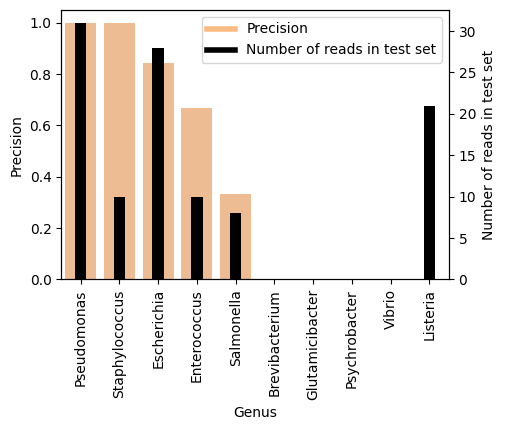

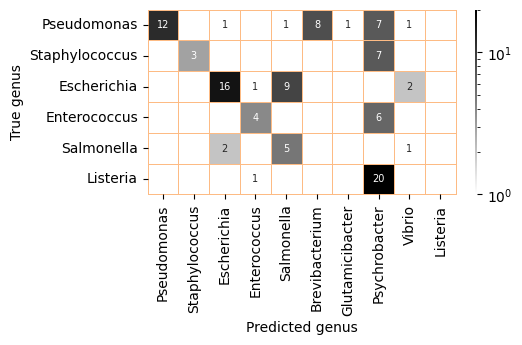

In [62]:
rank = "genus"
precision = per_class_scores_RF_genus[(per_class_scores_RF_genus["metric"]=="precision")].reset_index(drop=True).sort_values(by="score", ascending=False)
support = per_class_scores_RF_genus[(per_class_scores_RF_genus["metric"] == "support")].reset_index(drop=True)
png_file = f"{output_prefix}_precision_numreads_RF_genus.png"
precision_numreads_plot(precision, support, png_file, color)

ordered_classes = precision["class"].unique()
true_classes = [c for c in precision["class"].unique() if c in y_true_genus]
png_file = f"{output_prefix}_confusion_matrix_RF_genus.png"
plot_confusion_matrix(y_true_genus, y_pred_RF_genus, rank, ordered_classes, true_classes, png_file, color)

C:\Users\nicol\AppData\Local\Temp\ipykernel_8784\2530961771.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)


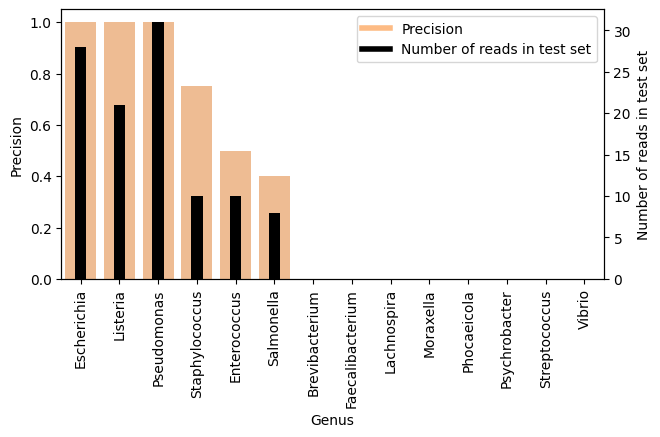

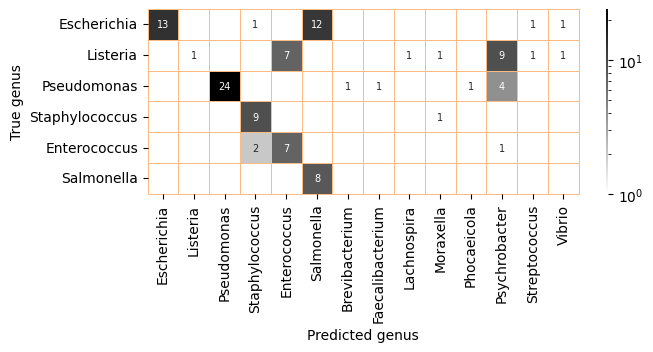

In [65]:
rank = "genus"
precision = per_class_scores_SVM_genus[(per_class_scores_SVM_genus["metric"]=="precision")].reset_index(drop=True).sort_values(by="score", ascending=False)
support = per_class_scores_SVM_genus[(per_class_scores_SVM_genus["metric"] == "support")].reset_index(drop=True)
png_file = f"{output_prefix}_precision_numreads_SVM_genus.png"
precision_numreads_plot(precision, support, png_file, color)

ordered_classes = precision["class"].unique()
true_classes = [c for c in precision["class"].unique() if c in y_true_genus]
png_file = f"{output_prefix}_confusion_matrix_SVM_genus.png"
plot_confusion_matrix(y_true_genus, y_pred_SVM_genus, rank, ordered_classes, true_classes, png_file, color)